# Decision Trees (Classification & Regression)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)

> **Scope**: the from-scratch twin in `src/models/tree_models.py` implements **both** the classifier
> (`DecisionTreeClassifierScratch`) and the regressor (`DecisionTreeRegressorScratch`). Both are
> exercised in §5; scikit-learn's versions get their turn in §6.

---

## 1. Introduction

### What is a Decision Tree?

A decision tree is a **hierarchical, rule-based** supervised learner. It repeatedly asks the simplest
possible question — *is feature $j$ below threshold $\tau$?* — and sends each sample down the matching
branch. Enough questions route every sample into a **leaf**, and the leaf's stored statistic is the
prediction: the **majority class** (classification) or the **mean target** (regression).

Geometrically, every question cuts the feature space with an **axis-aligned** boundary. A tree's
decision surface is therefore a union of **rectangles** — piecewise-constant regions stitched
together out of vertical and horizontal cuts. That is the single most useful mental image for
everything that follows: powerful (any decision boundary can be approximated to arbitrary fineness),
and the source of both the tree's strengths and its failures.

**Key characteristics:**
- **Supervised learning** for both classification and regression
- **Non-parametric** — no distribution assumptions; the model grows until stopping rules fire
- **Axis-aligned recursive partitioning** — every boundary is `feature ≤ threshold`
- **Interpretable** — the fitted model is a flowchart you can draw, read, and turn into rules
- **Scale-invariant** — splits compare values per feature, so scaling never matters (§3)
- **High variance alone** — small changes in the data can rebuild the tree (§5); ensembles fix this

**Historical Context:**
- Morgan & Sonquist (1963): AID, the first recursive-partitioning program
- Breiman, Friedman, Olshen & Stone (1984): **CART** — binary splits, Gini impurity, regression trees, cost-complexity pruning
- Quinlan (1986): **ID3** — entropy-based splitting for categorical features
- Quinlan (1993): **C4.5** — continuous thresholds, pruning, missing-value handling
- Today: the base learner inside Random Forests (notebook 04), Gradient Boosting (08), XGBoost/LightGBM/CatBoost (09–11)

**Main Use Cases:**
- **Rule extraction** for business or clinical review (credit decisions, diagnosis support)
- **Quick baselines** on tabular data with mixed feature types and no preprocessing
- **Feature importance triage** — which features actually move the prediction
- **The base learner of every tree ensemble** — arguably the tree's biggest role today

**How it works (simplified):**
1. Start at the root with all training rows
2. Search every (feature, threshold) candidate for the split that most reduces impurity
3. Partition the rows into a left and a right child
4. Recurse on each child until a stopping rule fires
5. Leaves store the prediction: majority class, class fractions, or the mean target

In [1]:
# Import necessary libraries
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_diabetes, load_iris, make_blobs, make_moons
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, mean_absolute_error, mean_squared_error,
                             precision_score, r2_score, recall_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree

sys.path.append('../src')
from models.tree_models import DecisionTreeClassifierScratch, DecisionTreeRegressorScratch

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')
print(f'NumPy version: {np.__version__}')
print(f'Pandas version: {pd.__version__}')
print('Scratch twins imported from src/models/tree_models.py')

Libraries imported successfully!
NumPy version: 2.5.1
Pandas version: 3.0.3
Scratch twins imported from src/models/tree_models.py


### Visual Intuition: The Axis-Aligned Staircase

The same interleaved-moons data that notebook 05 used for SVMs, fitted with two plain trees:

- a **shallow** tree sees only a couple of rectangles — the crescents are far beyond it
- an **unconstrained** tree traces the crescents as a **staircase** of axis-aligned cuts. The boundary
  is never a curve — it is many small right-angle steps

Every plot in this notebook draws regions the same way: predicted labels over a fine mesh, points on
top. These helpers are reused in §5–§7 and §11.

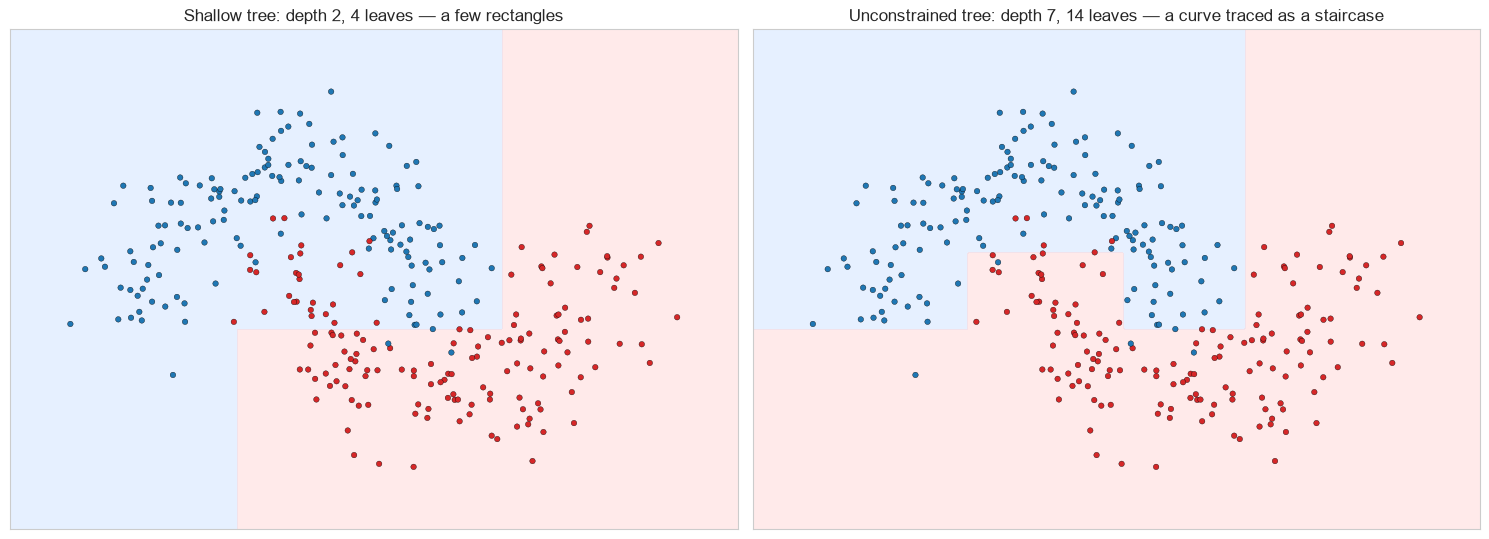

Shallow tree:  train accuracy 0.9033
Deep tree:     train accuracy 0.9733

💡 Both boundaries are made exclusively of axis-aligned cuts (vertical/horizontal lines).
   The deep tree can follow any shape by spending enough cuts — but "enough cuts" is exactly
   where overfitting lives. §7 shows how to pay for resolution with control instead of luck.


In [2]:
def region_panel(ax, model, X, y, title):
    # Predicted-label regions of a 2-D classifier fitted on raw coordinates (labels 0 and 1).
    pad = 0.4
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 300),
        np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 300),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=['#cfe2ff', '#ffd6d6'], alpha=0.5)
    ax.scatter(X[:, 0], X[:, 1], c=np.where(y == 1, '#d62728', '#1f77b4'), s=16,
               edgecolors='k', linewidths=0.25)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def draw_splits(ax, node, bounds0, bounds1, depth=0, max_lines=60):
    # Walk a scratch Node recursively and draw the axis-aligned cut of each internal
    # node, clipped to the rectangle region its subtree owns (so children stay inside parents).
    if node.is_leaf() or depth > max_lines:
        return
    if node.feature == 0:
        ax.plot([node.threshold, node.threshold], bounds1, color='white', lw=1.0, alpha=0.85)
        draw_splits(ax, node.left, (bounds0[0], node.threshold), bounds1, depth + 1)
        draw_splits(ax, node.right, (node.threshold, bounds0[1]), bounds1, depth + 1)
    else:
        ax.plot(bounds0, [node.threshold, node.threshold], color='white', lw=1.0, alpha=0.85)
        draw_splits(ax, node.left, bounds0, (bounds1[0], node.threshold), depth + 1)
        draw_splits(ax, node.right, bounds0, (node.threshold, bounds1[1]), depth + 1)


X_moon_g, y_moon_g = make_moons(n_samples=300, noise=0.2, random_state=42)

tree_shallow = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_moon_g, y_moon_g)
tree_deep = DecisionTreeClassifier(min_samples_leaf=6, random_state=42).fit(X_moon_g, y_moon_g)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
region_panel(axes[0], tree_shallow, X_moon_g, y_moon_g,
             f'Shallow tree: depth {tree_shallow.get_depth()}, {tree_shallow.get_n_leaves()} leaves '
             f'— a few rectangles')
region_panel(axes[1], tree_deep, X_moon_g, y_moon_g,
             f'Unconstrained tree: depth {tree_deep.get_depth()}, {tree_deep.get_n_leaves()} leaves '
             f'— a curve traced as a staircase')
plt.tight_layout()
plt.show()

print(f'Shallow tree:  train accuracy {tree_shallow.score(X_moon_g, y_moon_g):.4f}')
print(f'Deep tree:     train accuracy {tree_deep.score(X_moon_g, y_moon_g):.4f}')
print()
print('💡 Both boundaries are made exclusively of axis-aligned cuts (vertical/horizontal lines).')
print('   The deep tree can follow any shape by spending enough cuts — but "enough cuts" is exactly')
print('   where overfitting lives. §7 shows how to pay for resolution with control instead of luck.')

---

## 2. Theory & Mathematics

### Core Concept: Greedy Recursive Splitting

A tree is grown one node at a time. At every node the algorithm scores candidate splits, keeps the
one that reduces impurity the most, and recurses on the two children. Nothing is ever revisited:
this is **greedy** optimization. It is not globally optimal, but it is fast, and it works
remarkably well — especially once ensembles average away the greedy variance.

A candidate split at node $t$ is a (feature, threshold) pair $(f, \tau)$:

- **left child**: all rows with $x_f \le \tau$ — **right child**: all rows with $x_f > \tau$
- **quality** = impurity of the parent − size-weighted impurity of the two children

$$\text{gain}(t, f, \tau) = I(t) \;-\; \frac{|t_{\text{left}}|}{|t|}\,I(t_{\text{left}})
\;-\; \frac{|t_{\text{right}}|}{|t|}\,I(t_{\text{right}})$$

### Classification Trees: Impurity Measures

**1. Gini impurity** (CART, scikit-learn's default)

$$\text{Gini}(t) = 1 - \sum_{i=1}^{C} p_i^2$$

where $p_i$ is the proportion of class $i$ at node $t$. It answers: *how often would two random
rows from this node disagree?*

**2. Entropy** (ID3, C4.5)

$$\text{Entropy}(t) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

| Measure | Formula | Pure node | Binary maximum |
|---|---|---|---|
| Gini | $1 - \sum p_i^2$ | $0$ | $0.5$ at $p = 0.5$ |
| Entropy | $-\sum p_i \log_2 p_i$ | $0$ | $1.0$ at $p = 0.5$ |

Both peak when classes are balanced, both hit zero when a node is pure, and in practice they grow
**near-identical trees** (verified empirically in §5). Gini skips the logarithm, which is why
scikit-learn defaults to it.

### Regression Trees: Variance Reduction

The target is continuous, so \"impurity\" becomes squared error around the leaf mean $\bar{y}_t$:

$$\text{MSE}(t) = \frac{1}{|t|} \sum_{i \in t} (y_i - \bar{y}_t)^2, \qquad
\text{VR}(t, f, \tau) = \text{MSE}(t) - \frac{|t_L|}{|t|}\,\text{MSE}(t_L) - \frac{|t_R|}{|t|}\,\text{MSE}(t_R)$$

A regression leaf predicts the **mean** of its rows — which is exactly why regression tree
predictions are **piecewise constant**: flat within each leaf, jumping at every boundary.

### Stopping Criteria (when a node becomes a leaf)

1. **`max_depth`** reached
2. **`min_samples_split`** not met (too few rows to split further)
3. **Pure node** — one class only (classification) / near-zero variance (regression)
4. **No positive gain** — every candidate split fails to reduce impurity

### Computational Complexity

| Operation | Cost | Notes |
|---|---|---|
| Training | $O(n \cdot m \cdot u)$ per node for a brute-force scan ($u$ = unique values); scikit-learn sorts each feature once and scans, $O(n \cdot m \log n)$ | repeated at every node of the recursion |
| Prediction | $O(\text{depth})$ per sample | one comparison per level |
| Model size | $O(\text{nodes})$ | each internal node stores `(feature, threshold)`; each leaf stores its prediction |

### The Greedy Caveat

Greedy splitting finds **a** locally good tree, not the best tree — finding the globally minimal
impurity tree is NP-hard. A locally perfect split can block a globally better one two levels down.
Trees live with this the same way K-Means lives with local minima (notebook 12): the result is
good enough in practice, and ensembles (averaging many trees over resampled data — notebook 04)
turn the variance of greedy fits into a feature.

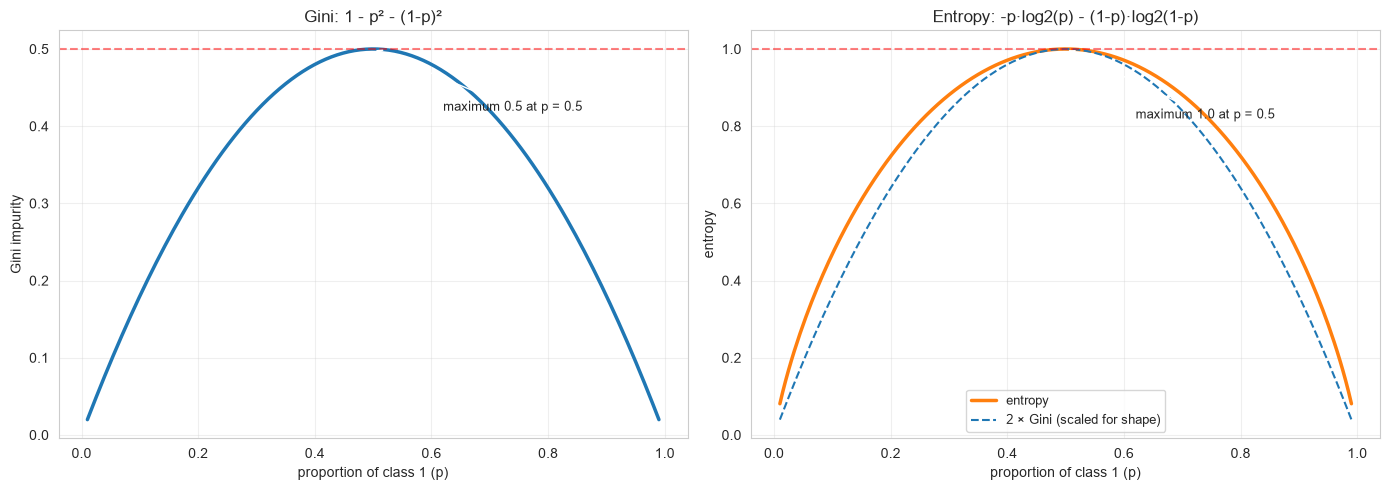

📊 Landmark values at p = 0.5 (maximum impurity):
  Gini    = 0.5000
  Entropy = 1.0000

💡 The dashed line shows why the two criteria are near-interchangeable: entropy is
   approximately a rescaled Gini over most of the range. They disagree on ties and on
   how strongly they punish moderately-imbalanced nodes — but rarely change the tree.


In [3]:
# Gini vs Entropy: same shape, same optimum, different scale
p = np.linspace(0.01, 0.99, 200)
gini = 1 - p**2 - (1 - p)**2
entropy = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p, gini, color='#1f77b4', lw=2.5)
axes[0].set_xlabel('proportion of class 1 (p)')
axes[0].set_ylabel('Gini impurity')
axes[0].set_title('Gini: 1 - p² - (1-p)²')
axes[0].axhline(0.5, color='red', ls='--', alpha=0.5)
axes[0].annotate('maximum 0.5 at p = 0.5', xy=(0.5, 0.5), xytext=(0.62, 0.42),
                 arrowprops=dict(arrowstyle='->'), fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(p, entropy, color='#ff7f0e', lw=2.5, label='entropy')
axes[1].plot(p, 2 * gini, color='#1f77b4', ls='--', lw=1.5, label='2 × Gini (scaled for shape)')
axes[1].set_xlabel('proportion of class 1 (p)')
axes[1].set_ylabel('entropy')
axes[1].set_title('Entropy: -p·log2(p) - (1-p)·log2(1-p)')
axes[1].axhline(1.0, color='red', ls='--', alpha=0.5)
axes[1].annotate('maximum 1.0 at p = 0.5', xy=(0.5, 1.0), xytext=(0.62, 0.82),
                 arrowprops=dict(arrowstyle='->'), fontsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('📊 Landmark values at p = 0.5 (maximum impurity):')
print(f'  Gini    = {1 - 0.5**2 - 0.5**2:.4f}')
print(f'  Entropy = {-0.5 * np.log2(0.5) - 0.5 * np.log2(0.5):.4f}')
print()
print('💡 The dashed line shows why the two criteria are near-interchangeable: entropy is')
print('   approximately a rescaled Gini over most of the range. They disagree on ties and on')
print('   how strongly they punish moderately-imbalanced nodes — but rarely change the tree.')

### A Worked Micro-Example: Choosing the Root Split by Hand

Ten rows, two features. Follow the arithmetic the code performs on every node of every tree in
this notebook — the exact rule `DecisionTreeClassifierScratch._best_split` implements:

1. Impurity of the root: 5 rows of class 0, 5 of class 1 → Gini $= 1 - 0.5^2 - 0.5^2 = 0.5$
2. For **every feature**, try **every unique value** as a threshold (rule: $x_f \le \tau$ goes left)
3. Score each candidate: weighted child Gini, then gain $= 0.5 - \text{weighted}$
4. Keep the candidate with the largest gain (first one wins ties, because the scan is ordered)

The dataset is built so feature 0 is (individually) nearly useless — its classes alternate —
while feature 1 separates the classes perfectly with one threshold. Greedy search finds that out
with pure arithmetic, no domain knowledge.

In [4]:
# The tiny dataset: classes alternate along x0, but x1 <= 3 separates them perfectly
X_micro = np.array([
    [5.0, 1.0], [95.0, 1.0], [15.0, 2.0], [85.0, 2.0], [45.0, 3.0],
    [55.0, 4.0], [65.0, 4.0], [35.0, 5.0], [75.0, 5.0], [25.0, 6.0],
])
y_micro = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# Root impurity by hand: 5 vs 5
root_gini = 1 - (5 / 10) ** 2 - (5 / 10) ** 2
print(f'Root Gini: 1 - (5/10)² - (5/10)² = {root_gini:.4f}')
print()

# Score every candidate the way the scratch twin does (unique values, x_f <= tau)
def gini_of(labels):
    props = np.bincount(labels, minlength=2) / len(labels)
    return 1 - np.sum(props ** 2)


rows_hand = []
for f in range(2):
    for tau in np.unique(X_micro[:, f]):
        left, right = y_micro[X_micro[:, f] <= tau], y_micro[X_micro[:, f] > tau]
        if len(left) == 0 or len(right) == 0:
            continue
        weighted = len(left) / 10 * gini_of(left) + len(right) / 10 * gini_of(right)
        rows_hand.append({'feature': f'x[{f}]', 'threshold': tau,
                          'weighted child Gini': weighted, 'gain': root_gini - weighted})

hand_df = pd.DataFrame(rows_hand).sort_values('gain', ascending=False).reset_index(drop=True)
print('Candidate splits, ranked by gain (best first):')
print(hand_df.round(4).to_string())

best = hand_df.iloc[0]
best_feature, best_tau, best_gain_v = best['feature'], best['threshold'], best['gain']
print()
print(f'✨ Best split: {best_feature} <= {best_tau:.1f} '
      f'(gain {best_gain_v:.4f}) — both children are pure, so the tree is DONE at depth 1')

# The scratch twin's own greedy scan must pick exactly this split
tree_micro = DecisionTreeClassifierScratch(max_depth=1, criterion='gini').fit(X_micro, y_micro)
print()
print(f'🌳 Scratch twin (max_depth=1) chose: feature {tree_micro.root.feature}, '
      f'threshold {tree_micro.root.threshold:.1f}')
print(f'   Left leaf majority: class {tree_micro.classes_[tree_micro.root.left.proba.argmax()]} '
      f'(fractions {tree_micro.root.left.proba.round(2)})')
print(f'   Right leaf majority: class {tree_micro.classes_[tree_micro.root.right.proba.argmax()]} '
      f'(fractions {tree_micro.root.right.proba.round(2)})')
print()
print('💡 Hand arithmetic and greedy scan agree. Any threshold between 3 and 4 on x[1] gives the')
print('   same partition (scikit-learn scans midpoints between sorted values — equivalent rule).')

Root Gini: 1 - (5/10)² - (5/10)² = 0.5000

Candidate splits, ranked by gain (best first):
   feature  threshold  weighted child Gini    gain
0     x[1]        3.0               0.0000  0.5000
1     x[1]        2.0               0.1667  0.3333
2     x[1]        4.0               0.2857  0.2143
3     x[0]       75.0               0.3750  0.1250
4     x[0]       15.0               0.3750  0.1250
5     x[1]        1.0               0.3750  0.1250
6     x[0]        5.0               0.4444  0.0556
7     x[0]       85.0               0.4444  0.0556
8     x[1]        5.0               0.4444  0.0556
9     x[0]       25.0               0.4762  0.0238
10    x[0]       65.0               0.4762  0.0238
11    x[0]       45.0               0.4800  0.0200
12    x[0]       55.0               0.5000  0.0000
13    x[0]       35.0               0.5000  0.0000

✨ Best split: x[1] <= 3.0 (gain 0.5000) — both children are pure, so the tree is DONE at depth 1

🌳 Scratch twin (max_depth=1) chose: feature 1,

### Watching a Tree Grow: The Partition, Depth by Depth

Fitting the scratch twin with `max_depth = 1, 2, 3, 5` and unconstrained on one dataset, and
drawing the actual partition after every fit. Each white line is one internal node's cut; the
colored background is what `predict` returns on a fine mesh.

This is the tree-side analogue of notebook 12's Lloyd's-algorithm frames: the algorithm's state,
visualized step by step.

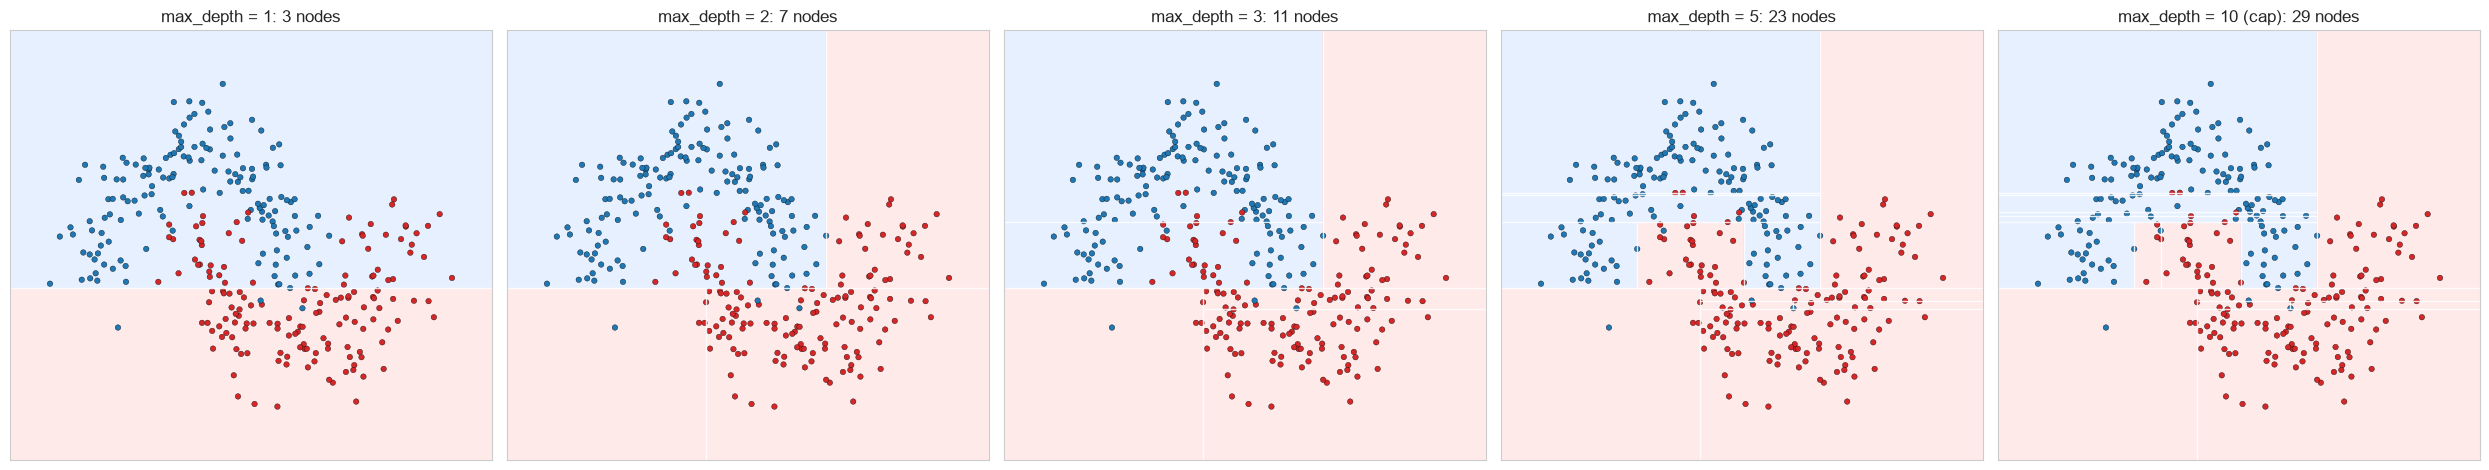

max_depth  nodes  train accuracy
        1      3          0.8133
        2      7          0.9000
        3     11          0.9000
        5     23          0.9733
       10     29          0.9733

💡 Two things climb together with depth: the fit to THIS sample (train accuracy → 1.0)
   and the number of rectangles. Nothing in that climb knows anything about generalization —
   which is why depth must be chosen out-of-sample (§7), not admired in-sample.


In [5]:
# Grow the same tree at increasing depth caps and draw each partition
depths_grow = [1, 2, 3, 5, 10]
fig, axes = plt.subplots(1, 5, figsize=(25, 4.8))
rows_grow = []

for ax, d in zip(axes, depths_grow):
    tree_g = DecisionTreeClassifierScratch(max_depth=d, min_samples_leaf=4).fit(X_moon_g, y_moon_g)
    region_panel(ax, tree_g, X_moon_g, y_moon_g,
                 f'max_depth = {d if d < 10 else "10 (cap)"}: {tree_g.count_nodes()} nodes')
    # scratch trees expose their Node objects — draw every internal cut, clipped to its region
    draw_splits(ax, tree_g.root,
                (X_moon_g[:, 0].min() - 0.4, X_moon_g[:, 0].max() + 0.4),
                (X_moon_g[:, 1].min() - 0.4, X_moon_g[:, 1].max() + 0.4))
    rows_grow.append({'max_depth': d if d < 10 else '10', 'nodes': tree_g.count_nodes(),
                      'train accuracy': tree_g.score(X_moon_g, y_moon_g)})

plt.tight_layout()
plt.show()

print(pd.DataFrame(rows_grow).to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print()
print('💡 Two things climb together with depth: the fit to THIS sample (train accuracy → 1.0)')
print('   and the number of rectangles. Nothing in that climb knows anything about generalization —')
print('   which is why depth must be chosen out-of-sample (§7), not admired in-sample.')

---

## 3. Assumptions & Requirements

Trees make almost no distributional assumptions — that is their signature advantage. What they
*do* assume is about **geometry and stability**, and most real failures trace back to these:

#### ✅ 1. **Axis-Aligned Splits Are Enough**
- Every cut is `feature ≤ threshold` — a tree cannot rotate. A diagonal or curved structure is
  approximated as a staircase of cuts, and the required cut count explodes with rotation angle
- **Test**: fit trees of increasing depth — if test accuracy needs depths that make train accuracy
  1.0, the geometry is fighting the model (the §2 staircase shows this directly)
- **Fix**: rotate/whiten features first, or use a model with oblique boundaries (SVM, notebook 05);
  in practice, ensembles absorb this (notebook 04)

#### ✅ 2. **Stable Data (Low Label Noise)**
- A few mislabeled rows deep in a pure region can spawn whole subtrees — an unconstrained tree
  will *carve exceptions for noise*
- **Test**: train-test gap under increasing depth (§7); the gap widens exactly where noise is
  being memorized
- **Fix**: depth/leaf constraints, `min_impurity_decrease`, or `ccp_alpha` pruning (§7)

#### ✅ 3. **Enough Rows per Leaf**
- A leaf's prediction is its rows' majority/mean. Leaves with 2–3 rows produce high-variance,
  unreliable predictions
- **Test**: `get_n_leaves()` vs `n_samples`, and the depth of typical leaves
- **Fix**: `min_samples_leaf` (the most underrated tree hyperparameter, §7)

#### ✅ 4. **Independent, Identically Distributed Rows**
- Same contract as every supervised learner: training and future rows from the same distribution
- **Violation fix**: time-aware or group-aware splits for temporal/clustered data

#### ✅ 5. **No Missing Values (scikit-learn)**
- sklearn's trees raise on NaN. (Modern gradient-boosting libraries learned to route missings
  natively; plain CART handles them with surrogate splits — the scratch twin does neither)
- **Fix**: impute before fitting (§10's real examples need none of this — bundled data is complete)

### What Trees Do NOT Require (and what that buys you)

✅ **No feature scaling** — splits are per-feature order comparisons; a feature in microns and one
in kilometers are treated identically (demonstrated below)
✅ **No linearity, no monotonicity, no distribution shape** — threshold effects, interactions, and
jumps are all first-class citizens
✅ **No encoding gymnastics for multi-class targets** — sklearn's tree is natively multi-class
(no one-vs-one/one-vs-rest machinery, unlike SVC in notebook 05)

### When Assumptions Are Violated

| Violation | Symptom | Fix |
|---|---|---|
| Rotated/curved class geometry | Depth explodes; deep tree still jagged | Whiten/rotate features; ensembles; oblique models |
| Noisy labels + no depth cap | Train accuracy → 1.0, test accuracy drops | `max_depth` / `min_samples_leaf` / pruning |
| Tiny leaves | Erratic predictions near boundaries | `min_samples_leaf ≥ 5–10` |
| Extrapolation asked of the model | Predictions clamp at edge-leaf values | Use a linear model for trend tasks |
| Missing values fed to sklearn tree | `ValueError` on fit | Impute in a pipeline |

### Key Differences from Linear Models (notebooks 01–02)

| Aspect | Decision Trees | Linear Models |
|---|---|---|
| Boundary shape | Axis-aligned steps | A straight hyperplane |
| Feature scaling | Not needed | Required (for stability/speed) |
| Interactions | Automatic (deeper splits refine shallower ones) | Manual (engineered terms) |
| Extrapolation | ❌ clamps to leaf values | ✅ follows the trend |
| Interpretation | A drawn flowchart | Coefficients |
| Overfitting risk | High if unconstrained | Low (with regularization) |

> **The demo that follows** contrasts with notebook 05's §3: there, ignoring scaling destroyed an
> RBF SVM. Here, the same neglect costs a tree nothing — and the demo also shows sklearn's hard
> stop on NaN inputs.

In [6]:
# Scale-invariance: one feature in 'microns', one in 'meters' — the tree does not care
rng3 = np.random.default_rng(42)
n3 = 400
f_tiny = rng3.normal(0.0015, 0.0002, n3)      # values around 0.0015
f_big = rng3.normal(50000.0, 15000.0, n3)     # values around 50,000
# an OR-rule target: either feature alone carries signal (needs two nested splits)
y3 = ((f_tiny > 0.0015) | (f_big > 50000)).astype(int)
X3 = np.column_stack([f_tiny, f_big])

tree_raw = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X3, y3)
X3_std = StandardScaler().fit_transform(X3)
tree_std = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X3_std, y3)

print('=' * 60)
print('SCALE-INVARIANCE DEMO: SAME TREE, RAW vs STANDARDIZED FEATURES')
print('=' * 60)
print(f'Feature ranges:  f_tiny [{f_tiny.min():.4f}, {f_tiny.max():.4f}]   '
      f'f_big [{f_big.min():.0f}, {f_big.max():.0f}]')
print(f'Range ratio (f_big / f_tiny): {np.ptp(f_big) / np.ptp(f_tiny):,.0f}×')
print()
print(f'Tree on RAW features:          train accuracy {tree_raw.score(X3, y3):.4f}')
print(f'Tree on STANDARDIZED features: train accuracy {tree_std.score(X3_std, y3):.4f}')
print()
print('💡 Standardization changes the printed thresholds, not the partition — order comparisons')
print('   are invariant to per-feature rescaling. Contrast notebook 05 §3, where the same neglect')
print('   wrecked an RBF SVM.')

# sklearn trees refuse NaN inputs
X3_nan = X3.copy()
X3_nan[0, 0] = np.nan
try:
    DecisionTreeClassifier(max_depth=3).fit(X3_nan, y3)
except ValueError as exc:
    print(f'❌ Fitting with a NaN present raises: ValueError: {str(exc).strip()[:90]}...')
print('💡 Missing values must be imputed first — inside a Pipeline so CV folds stay clean (§9).')

SCALE-INVARIANCE DEMO: SAME TREE, RAW vs STANDARDIZED FEATURES
Feature ranges:  f_tiny [0.0010, 0.0021]   f_big [5532, 88965]
Range ratio (f_big / f_tiny): 76,117,800×

Tree on RAW features:          train accuracy 1.0000
Tree on STANDARDIZED features: train accuracy 1.0000

💡 Standardization changes the printed thresholds, not the partition — order comparisons
   are invariant to per-feature rescaling. Contrast notebook 05 §3, where the same neglect
   wrecked an RBF SVM.
💡 Missing values must be imputed first — inside a Pipeline so CV folds stay clean (§9).


---

## 4. When to Use This Algorithm

### ✅ Use a Decision Tree When:

1. **The model itself must be explainable**
    - Credit, clinical, and policy decisions where \"why\" is a deliverable
    - A fitted tree can be drawn (`plot_tree`, §6), exported as text rules (`export_text`, §10),
      and walked by hand — the entire decision process is auditable
2. **Tabular data with mixed feature types and scales**
    - No scaling, no encoding beyond what the library requires, no normality — the least
      preprocessing of any algorithm in this series
3. **Threshold effects, jumps, and interactions dominate**
    - \"If tenure < 6 months AND monthly charges > $80 → churn\" is a tree's native language;
      linear models need engineered interaction terms for the same structure
4. **You need a fast, honest baseline**
    - Seconds to fit, no tuning to be respectable, and it defines the difficulty floor for
      fancier models (§11 measures this)
5. **You are building an ensemble**
    - Bagged or boosted trees are the industry's default tabular learner (notebooks 04, 08–11);
      understanding this section is the prerequisite for all of them
6. **Multi-class targets**
    - Handled natively in one tree — no one-vs-one tournament (SVC, notebook 05) or softmax (NN)

### ❌ Avoid a Single Decision Tree When:

1. **Smooth predictions matter**
    - Regression output is a staircase; a smooth curve needs many deep leaves → variance
      (logistic regression, linear models, or ensembles instead)
2. **Extrapolation matters**
    - New inputs outside the training range get clamped to the edge leaf's value (§10 Example 2
      shows the plateau) — trees have no trend model
3. **The dataset is small and noisy**
    - High variance + few rows = unstable, overfit trees (§5 demonstrates the instability directly)
4. **Best-possible accuracy is the goal**
    - A single tree is rarely the strongest model — its ensembles are (notebook 04, 08–11)
    - Production rule of thumb: a single tree for explanation, an ensemble for prediction
5. **Features are sparse and high-dimensional** (raw text, one-hot with thousands of columns)
    - Axis-aligned splits weaken as dimension grows; linear models and Naive Bayes (06) are
      stronger there

### Classification vs Regression

| Task | Fit for trees | Watch out for |
|---|---|---|
| **Classification** | ✅ multi-class natively, threshold effects, `class_weight='balanced'` for imbalance | coarse leaf probabilities (few distinct values, §10) |
| **Regression** | ✅ non-linear targets, interactions | staircase predictions; no extrapolation |

### Trees vs the Neighbors (short version; measured in §11)

- **vs Logistic Regression (02)**: trees model jumps and interactions natively; logistic gives
  smooth probabilities and extrapolates
- **vs SVM (05)**: trees need no scaling and explain themselves; SVMs bend boundaries smoothly
  with kernels but are black-box at the feature level
- **vs Random Forest (04)**: the forest is many of these trees on resampled data — more accurate
  and stable, less interpretable; if you like this notebook's rules but distrust their variance,
  notebook 04 is the fix

---

## 5. Implementation from Scratch (NumPy)

### Why Implement Trees from Scratch?

- The recursion looks like magic until you have watched one split's arithmetic end-to-end (§2's
  micro-example) and one full build (this section)
- The tree structure becomes a **concrete object** you can walk: `root`, `left`, `right`,
  `threshold`, leaf fractions — instead of an opaque `.tree_` array
- It exposes the decisions sklearn hides: what counts as a candidate split, when recursion stops,
  and what a leaf actually stores

The from-scratch twin lives in `src/models/tree_models.py` as **`DecisionTreeClassifierScratch`**
and **`DecisionTreeRegressorScratch`**, shared with notebook 04's forests (the forest is a
bootstrap ensemble over this same recursion) and the gradient booster (which reuses the
regressor's leaves via `apply()`). Both mirror sklearn's API surface: `fit` / `predict` /
`predict_proba` (classifier) / `score`, plus `get_depth()` and `count_nodes()`.

What is deliberately simplified (documented in the module, and covered in the guided tour below):

- **Exhaustive split search** — every feature × every unique value, $O(n \cdot m \cdot u)$ per node.
  sklearn sorts once per feature and scans. Same partitions, slower scan
- **No** `splitter='random'`, no `max_features`, no `class_weight`, no `ccp_alpha` post-pruning,
  no surrogate splits for missing values
- `max_depth` **defaults to 10**, not sklearn's `None` — pass it explicitly when comparing engines
- Prediction walks the tree recursively per sample — fine for demos, not vectorized like sklearn

In [7]:
# Import our from-scratch implementation (also done at the top; repeated here for the tour)
import sys
sys.path.append('../src')

from models.tree_models import DecisionTreeClassifierScratch, DecisionTreeRegressorScratch

print('✅ Imported custom Decision Tree implementations!')
print()
print('Available classes:')
print("  • DecisionTreeClassifierScratch(max_depth=10, min_samples_split=2, min_samples_leaf=1, criterion='gini')")
print('  • DecisionTreeRegressorScratch(max_depth=10, min_samples_split=2, min_samples_leaf=1)')
print()
print('API (mirrors scikit-learn names):')
print('  • .fit(X, y) grows the tree greedily')
print('  • .predict(X) / .predict_proba(X) / .score(X, y)')
print('  • .root (Node tree), .classes_, .get_depth(), .count_nodes()')
print('  • regressor extra: .apply(X) → leaf Node per row (gradient-boosting hook)')

✅ Imported custom Decision Tree implementations!

Available classes:
  • DecisionTreeClassifierScratch(max_depth=10, min_samples_split=2, min_samples_leaf=1, criterion='gini')
  • DecisionTreeRegressorScratch(max_depth=10, min_samples_split=2, min_samples_leaf=1)

API (mirrors scikit-learn names):
  • .fit(X, y) grows the tree greedily
  • .predict(X) / .predict_proba(X) / .score(X, y)
  • .root (Node tree), .classes_, .get_depth(), .count_nodes()
  • regressor extra: .apply(X) → leaf Node per row (gradient-boosting hook)


### Classification Example (From Scratch)

The §1 moons geometry, now split honestly into train/test. Two trees: Gini and entropy, identical
hyperparameters. Trees need **no scaling** — the raw coordinates go straight in, a deliberate
contrast with notebook 05 where the same data had to be standardized before an SVM could touch it.

In [8]:
# Same moons as §1, now split honestly; no scaler in sight — trees don't need one
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_moon_g, y_moon_g, test_size=0.3,
                                              stratify=y_moon_g, random_state=42)

print('=' * 60)
print('DECISION TREE CLASSIFIER (FROM SCRATCH)')
print('=' * 60)
print()
print('📊 Dataset:')
print(f'  Training samples: {len(Xm_tr)}')
print(f'  Test samples:     {len(Xm_te)}')
print(f'  Features:         {Xm_tr.shape[1]}')

tree_gini_s = DecisionTreeClassifierScratch(max_depth=5, min_samples_split=10,
                                            min_samples_leaf=5, criterion='gini').fit(Xm_tr, ym_tr)
tree_entropy_s = DecisionTreeClassifierScratch(max_depth=5, min_samples_split=10,
                                               min_samples_leaf=5, criterion='entropy').fit(Xm_tr, ym_tr)

rows_scr = []
for name, m in [('gini', tree_gini_s), ('entropy', tree_entropy_s)]:
    rows_scr.append({'criterion': name,
                     'train acc': m.score(Xm_tr, ym_tr),
                     'test acc': m.score(Xm_te, ym_te),
                     'depth': m.get_depth(),
                     'nodes': m.count_nodes()})
print()
print('📈 Results:')
print(pd.DataFrame(rows_scr).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

agree_crit = np.mean(tree_gini_s.predict(Xm_te) == tree_entropy_s.predict(Xm_te))
print()
print(f'🤝 Gini vs entropy prediction agreement on test rows: {agree_crit:.1%}')
print()
print('💡 Near-identical accuracy and tree size — the criterion choice is rarely the lever people')
print('   think it is. Depth and leaf sizes (§7) are where the model complexity actually lives.')

DECISION TREE CLASSIFIER (FROM SCRATCH)

📊 Dataset:
  Training samples: 210
  Test samples:     90
  Features:         2

📈 Results:
criterion  train acc  test acc  depth  nodes
     gini     0.9667    0.9000      5     23
  entropy     0.9714    0.8778      5     23

🤝 Gini vs entropy prediction agreement on test rows: 95.6%

💡 Near-identical accuracy and tree size — the criterion choice is rarely the lever people
   think it is. Depth and leaf sizes (§7) are where the model complexity actually lives.


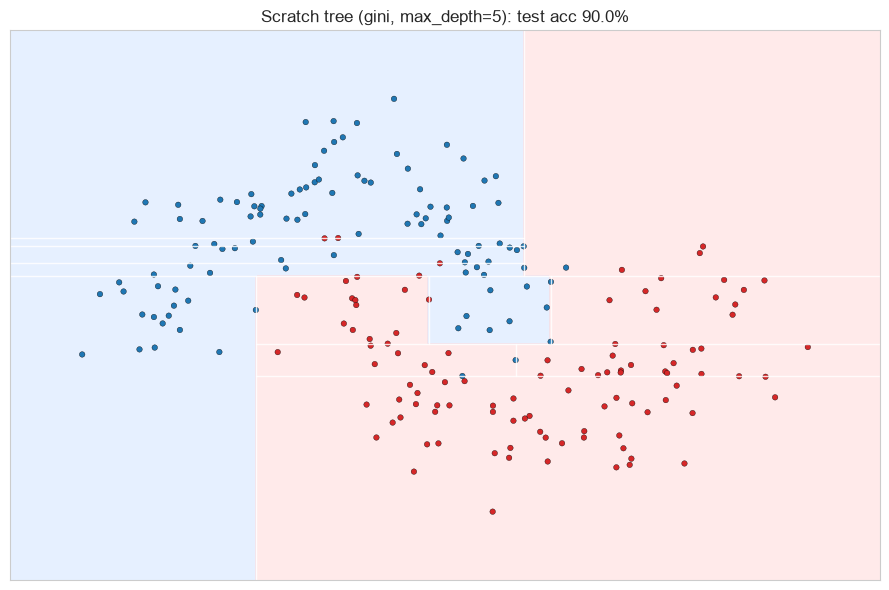

💡 Every white line is the rule of one internal node. The staircase is the whole model —
   there is no hidden geometry beyond these rectangles.


In [9]:
# The scratch tree's boundary on the moons, with every internal cut drawn
fig, ax = plt.subplots(figsize=(9, 6))
region_panel(ax, tree_gini_s, Xm_tr, ym_tr,
             f'Scratch tree (gini, max_depth=5): test acc {tree_gini_s.score(Xm_te, ym_te):.1%}')
draw_splits(ax, tree_gini_s.root,
            (Xm_tr[:, 0].min() - 0.4, Xm_tr[:, 0].max() + 0.4),
            (Xm_tr[:, 1].min() - 0.4, Xm_tr[:, 1].max() + 0.4))
plt.tight_layout()
plt.show()

print('💡 Every white line is the rule of one internal node. The staircase is the whole model —')
print('   there is no hidden geometry beyond these rectangles.')

### Reconstructing a Prediction by Hand

`predict` is literally a walk down the stored `Node` objects: at each internal node compare
`x[feature] <= threshold`, go left or right, stop at a leaf, return its majority class.
`predict_proba` returns that same leaf's stored class **fractions** — the exact empirical
distribution of its training rows. Below, three test rows are traced through the fitted tree,
printing every rule on the way down.

In [10]:
def trace_path(tree, x):
    node, steps = tree.root, []
    while not node.is_leaf():
        go_left = x[node.feature] <= node.threshold
        cmp_txt = '<=' if go_left else ' >'
        steps.append(f'x[{node.feature}] = {x[node.feature]:+.3f} {cmp_txt} {node.threshold:+.3f}  '
                     f'→ {"left" if go_left else "right"}')
        node = node.left if go_left else node.right
    return steps, node


proba_te_s = tree_gini_s.predict_proba(Xm_te)
conf_s = np.abs(proba_te_s[:, 1] - 0.5)
wrong_s = np.flatnonzero(tree_gini_s.predict(Xm_te) != ym_te)
picked_s = [
    ('most confident 1', int(np.argmax(proba_te_s[:, 1]))),
    ('least certain', int(np.argmin(conf_s))),
]
if len(wrong_s):
    picked_s.append(('misclassified', int(wrong_s[0])))

print('=' * 60)
print('HAND TRACING TEST ROWS DOWN THE FITTED TREE')
print('=' * 60)
for label, i in picked_s:
    x_row = Xm_te[i]
    steps, leaf = trace_path(tree_gini_s, x_row)
    pred_cls = tree_gini_s.classes_[leaf.value]
    print(f'🎯 {label}: test row {i}, true class {ym_te[i]}')
    for s in steps:
        print(f'   {s}')
    print(f'   🍃 leaf fractions {leaf.proba.round(3)} → predict_proba row: {proba_te_s[i].round(3)} → predict {pred_cls}')
    print()

agree_trace = tree_gini_s.classes_[np.array([trace_path(tree_gini_s, x)[1].value for x in Xm_te])]
print(f'🤝 Hand-walked predictions match .predict() on all {len(Xm_te)} test rows: '
      f'{np.array_equal(agree_trace, tree_gini_s.predict(Xm_te))}')
print()
print('💡 predict = argmax of the leaf class fractions, and predict_proba IS that leaf empirical')
print('   distribution — the same contract tests/models/test_tree_models.py pins down.')

HAND TRACING TEST ROWS DOWN THE FITTED TREE
🎯 most confident 1: test row 0, true class 1
   x[1] = -0.874 <= +0.469  → left
   x[0] = +1.590  > -0.510  → right
   x[1] = -0.874 <= +0.071  → left
   x[1] = -0.874 <= -0.119  → left
   🍃 leaf fractions [0. 1.] → predict_proba row: [0. 1.] → predict 1

🎯 least certain: test row 13, true class 0
   x[1] = +0.688  > +0.469  → right
   x[0] = +0.225 <= +0.974  → left
   x[1] = +0.688 <= +0.690  → left
   x[1] = +0.688  > +0.644  → right
   🍃 leaf fractions [0.6 0.4] → predict_proba row: [0.6 0.4] → predict 0

🎯 misclassified: test row 10, true class 0
   x[1] = +0.065 <= +0.469  → left
   x[0] = +0.774  > -0.510  → right
   x[1] = +0.065 <= +0.071  → left
   x[1] = +0.065  > -0.119  → right
   x[0] = +0.774 <= +0.930  → left
   🍃 leaf fractions [0.2 0.8] → predict_proba row: [0.2 0.8] → predict 1

🤝 Hand-walked predictions match .predict() on all 90 test rows: True

💡 predict = argmax of the leaf class fractions, and predict_proba IS that lea

### Regression Example (From Scratch)

A 1-D noisy curve — trend plus a wave plus noise. Two scratch regressors: `max_depth=3`
(a handful of leaf means = coarse steps) and `max_depth=10` (a leaf per few points = the noise
memorized). The staircase is not a rendering artifact: it **is** the model.

DECISION TREE REGRESSOR (FROM SCRATCH)
       model  train R²  test R²  depth  nodes
 max_depth=3    0.8185   0.8403      3     15
max_depth=10    0.9994   0.7433     10    295


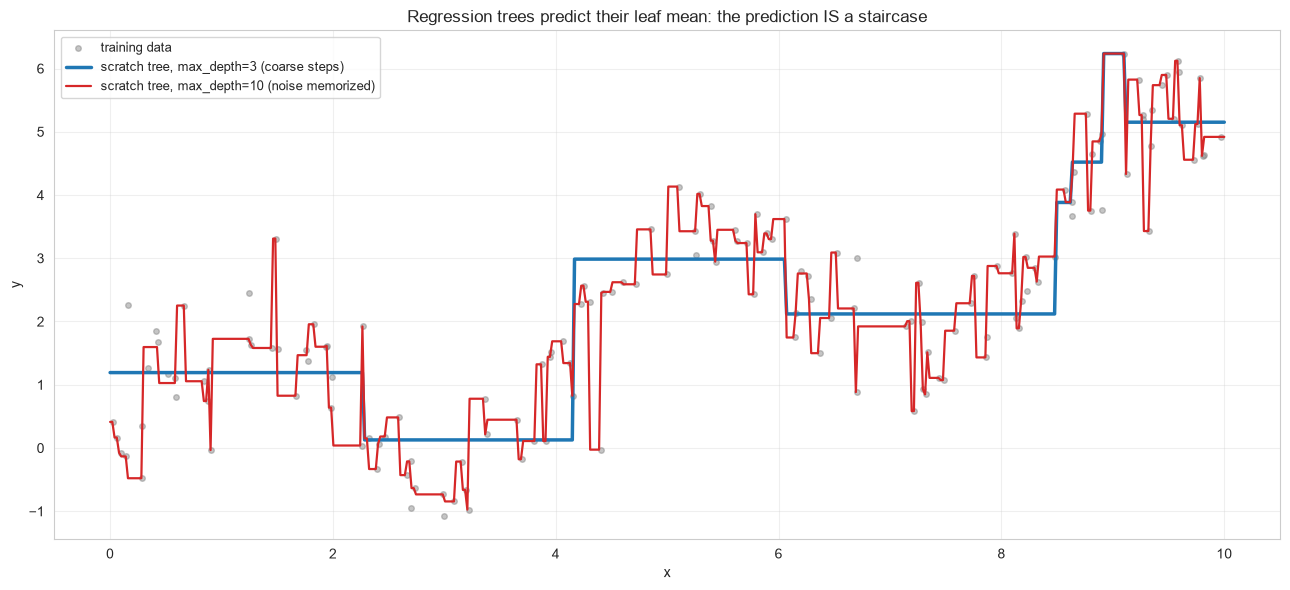

💡 Depth-3 steps average ~30 points per leaf → smooth-ish trend, wave half-visible.
   Depth-10 leaves isolate a few points each → train R² climbs, test R² pays for it.
   No depth value is right in general — §7 tunes it out-of-sample, every time.


In [11]:
# The curve: gentle trend + wave + noise (noise big enough that memorization is visible)
rng_curve = np.random.default_rng(0)
x_curve = np.sort(rng_curve.uniform(0.0, 10.0, 220)).reshape(-1, 1)
y_curve = 0.4 * x_curve[:, 0] + 1.5 * np.sin(1.5 * x_curve[:, 0]) + rng_curve.normal(0, 0.6, 220)
xc_tr, xc_te, yc_tr, yc_te = train_test_split(x_curve, y_curve, test_size=0.3, random_state=42)

tree_r3_s = DecisionTreeRegressorScratch(max_depth=3).fit(xc_tr, yc_tr)
tree_r10_s = DecisionTreeRegressorScratch(max_depth=10).fit(xc_tr, yc_tr)

grid_c = np.linspace(0.0, 10.0, 500).reshape(-1, 1)

print('=' * 60)
print('DECISION TREE REGRESSOR (FROM SCRATCH)')
print('=' * 60)
rows_reg = []
for name, m in [('max_depth=3', tree_r3_s), ('max_depth=10', tree_r10_s)]:
    rows_reg.append({'model': name,
                     'train R²': m.score(xc_tr, yc_tr),
                     'test R²': m.score(xc_te, yc_te),
                     'depth': m.get_depth(),
                     'nodes': m.count_nodes()})
print(pd.DataFrame(rows_reg).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(xc_tr, yc_tr, s=16, alpha=0.45, color='gray', label='training data')
ax.plot(grid_c, tree_r3_s.predict(grid_c), color='#1f77b4', lw=2.5,
        label='scratch tree, max_depth=3 (coarse steps)')
ax.plot(grid_c, tree_r10_s.predict(grid_c), color='#d62728', lw=1.6,
        label='scratch tree, max_depth=10 (noise memorized)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Regression trees predict their leaf mean: the prediction IS a staircase')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 Depth-3 steps average ~30 points per leaf → smooth-ish trend, wave half-visible.')
print('   Depth-10 leaves isolate a few points each → train R² climbs, test R² pays for it.')
print('   No depth value is right in general — §7 tunes it out-of-sample, every time.')

### Instability: One Tree's Achilles' Heel

A tree's most famous weakness, shown rather than told. Eight bootstrap resamples of the *same*
210 training rows, the *same* hyperparameters, eight fits. If the tree were stable, all eight
would agree on the root split and on the boundary. Watch what actually happens.

 fit    root split  depth  nodes  test acc
   0 x[1] <= 0.356      4     21    0.8556
   1 x[1] <= 0.469      4     13    0.8222
   2 x[1] <= 0.152      4     15    0.8556
   3 x[1] <= 0.342      4     15    0.8222
   4 x[1] <= 0.469      4     17    0.7778
   5 x[1] <= 0.455      4     15    0.8444
   6 x[1] <= 0.071      4     13    0.8333
   7 x[1] <= 0.503      4     15    0.8667

📊 Test accuracy across 8 resamples: min 0.7778, mean 0.8347, max 0.8667 (spread 0.0889)
📊 Distinct root splits among the 8 fits: 7 of 8


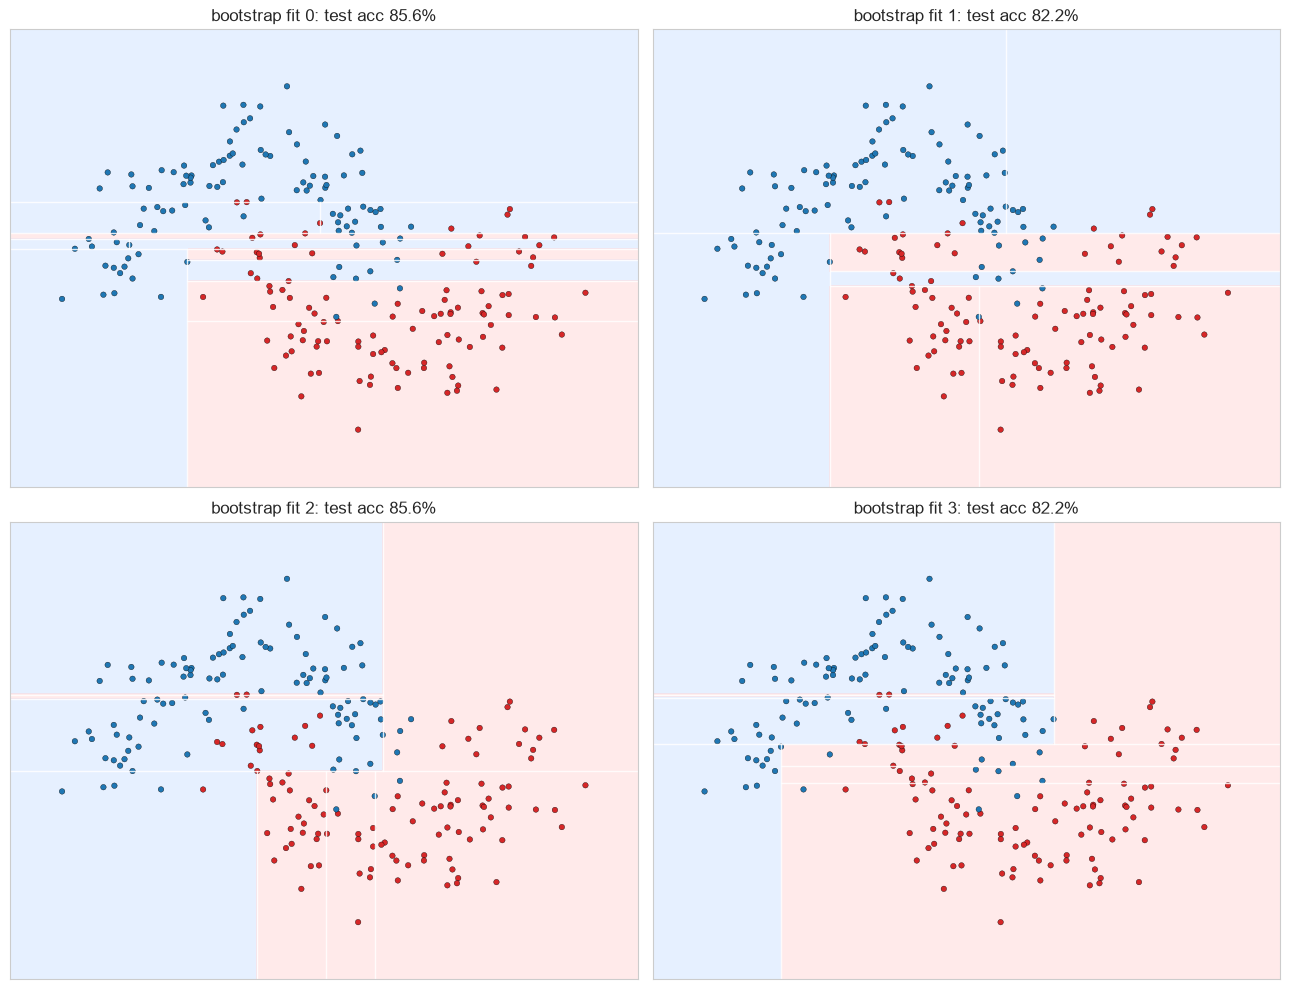

💡 Same algorithm, same data — different trees. That is **variance**, the greedy recursion
   amplifying whatever rows happen to be in the sample. Notebook 04 Random Forest is the
   fix (average 100+ of these), and §7 cross-validation is the honest way to measure it.


In [12]:
# Bootstrap the training rows 8 times, refit, and compare what the greedy search chose
rng_boot = np.random.default_rng(0)
rows_boot, boot_trees = [], []
for b in range(8):
    idx_b = rng_boot.integers(0, len(Xm_tr), len(Xm_tr))
    tree_b = DecisionTreeClassifierScratch(max_depth=4, min_samples_leaf=5).fit(Xm_tr[idx_b], ym_tr[idx_b])
    root_desc = ('leaf-only tree' if tree_b.root.is_leaf() else
                 f'x[{tree_b.root.feature}] <= {tree_b.root.threshold:.3f}')
    rows_boot.append({
        'fit': b,
        'root split': root_desc,
        'depth': tree_b.get_depth(),
        'nodes': tree_b.count_nodes(),
        'test acc': tree_b.score(Xm_te, ym_te),
    })
    boot_trees.append(tree_b)

boot_df = pd.DataFrame(rows_boot)
print(boot_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
accs_b = boot_df['test acc'].to_numpy()
print()
print(f'📊 Test accuracy across 8 resamples: min {accs_b.min():.4f}, '
      f'mean {accs_b.mean():.4f}, max {accs_b.max():.4f} (spread {accs_b.max() - accs_b.min():.4f})')
print(f'📊 Distinct root splits among the 8 fits: {boot_df["root split"].nunique()} of 8')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, b in zip(axes.ravel(), range(4)):
    region_panel(ax, boot_trees[b], Xm_tr, ym_tr, f'bootstrap fit {b}: test acc {accs_b[b]:.1%}')
    draw_splits(ax, boot_trees[b].root,
                (Xm_tr[:, 0].min() - 0.4, Xm_tr[:, 0].max() + 0.4),
                (Xm_tr[:, 1].min() - 0.4, Xm_tr[:, 1].max() + 0.4))
plt.tight_layout()
plt.show()

print('💡 Same algorithm, same data — different trees. That is **variance**, the greedy recursion')
print('   amplifying whatever rows happen to be in the sample. Notebook 04 Random Forest is the')
print('   fix (average 100+ of these), and §7 cross-validation is the honest way to measure it.')

### How the Scratch Version Works (a guided tour)

Read `src/models/tree_models.py` alongside these facts:

**1. Impurity is `np.bincount` arithmetic (`_gini`, `_entropy`).**
Leaf-eligible labels are contiguous integers (fact 4), so `np.bincount(y) / len(y)` gives the class
proportions in one pass. Gini is $1 - \sum p^2$; entropy is $-\sum p \log_2 p$ over the non-zero
proportions, with a `+1e-10` guard so the log never sees zero. `_impurity` dispatches on
`self.criterion`.

**2. The split search is exhaustive and greedy (`_best_split`).**
For each feature, for each unique value of that feature, the mask `x[f] <= τ` defines the two
children. Candidates that would leave either child smaller than `min_samples_leaf` are skipped
before scoring. Each survivor is scored by `_information_gain`: parent impurity minus the
size-weighted child impurity. `best_gain` starts at −1 and only a strictly greater gain replaces
it — so on ties, the **first** candidate in scan order (features ascending, then thresholds
ascending) wins. Deterministic, and exactly the arithmetic §2's micro-example reproduced.

**3. Recursion has four exits (`_build_tree`).**
A node becomes a leaf when `depth ≥ max_depth`, when fewer than `min_samples_split` rows remain,
when the node holds a single class, or when the best split found no positive gain (`best_feature`
is `None` or `best_gain == 0`). No other stopping logic exists — no `min_impurity_decrease`, no
leaf-count cap.

**4. Labels are remapped, not assumed (`fit`).**
`np.unique(y)` sorts the labels and `np.searchsorted` turns each row's label into its index in
that sorted list. This matters because everything downstream (`bincount`, leaf `value` storage)
needs contiguous 0..C−1 integers — arbitrary labels like `{10, 20}` or even strings would break
`bincount` otherwise. `classes_` remembers the originals; `predict` maps indices back through it,
which is why fitted predictions always come out in the labels you fed in.

**5. A leaf stores two things (`_leaf`).**
`value` = the **index** of the majority class (`argmax` of the counts) — what `predict` returns
after mapping back through `classes_`. `proba` = the **full class-fraction vector**
(`counts / len(y)`) — what `predict_proba` returns for every row routed to that leaf. Two surfaces,
one storage, guaranteed consistent: the argmax of `proba` is by construction the majority class
(`test_argmax_of_proba_matches_predict` in `tests/models/test_tree_models.py` pins this row by row).

**6. The regressor is the same recursion with a different score (`DecisionTreeRegressorScratch`).**
`_variance_reduction` replaces information gain: parent MSE minus size-weighted child MSE. The
stopping rules are the same plus a near-constant check (`MSE < 1e-7`), and a leaf stores the
**mean** of its targets instead of a class. `score` is R². It also exposes `apply(X)`, which
returns the leaf `Node` objects themselves — the hook `ensemble_models.py` gradient booster
uses to regroup samples per leaf and overwrite leaf values stage by stage.

**7. Introspection is a recursion, not bookkeeping.**
`get_depth()` and `count_nodes()` re-walk the `Node` tree on demand. There is no cached depth or
node count — the structure itself is the source of truth, which is what makes the instability
demo's per-fit measurements trustworthy.

**8. What the twin deliberately leaves out.** No `splitter`/`max_features` (every node scans every
feature), no `class_weight` (no per-class loss reweighting), no `ccp_alpha` (no post-pruning —
limits are applied while growing), no surrogate splits (a row with a missing value simply has no
path), and the `max_depth` default is 10 rather than sklearn's unbounded `None`. The brute-force
scan is the honest cost of clarity: the partitions match sklearn's, the wall-clock does not, which
is why every scratch demo here stays in the few-hundred-rows regime.

---

## 6. Implementation with Scikit-learn

scikit-learn's `DecisionTreeClassifier` / `DecisionTreeRegressor` are optimized CART: the split
search sorts each feature once and scans it (instead of the twin's brute-force rescan), growth is
depth-first in C, and the fitted tree is exposed through a flat `tree_` array
(`tree_.feature`, `tree_.threshold`, `tree_.value`, …). A few API facts worth pinning before the
first fit:

- **No scaler, ever** — raw features go straight in (§3 demonstrated why)
- **`max_depth` defaults to `None`** — unconstrained growth. The twin defaults to 10 instead.
  Unconstrained + noisy data is the textbook overfit recipe, so *always* set it or prune (§7)
- **`predict_proba` = leaf class fractions** — the same contract the twin implements; probabilities
  are quantized to whatever fractions the leaves hold (§10 shows the histogram)
- **Multi-class is native** — one tree, no one-vs-one tournament (contrast SVC, notebook 05)
- **Extras the twin lacks**: `apply()`, `decision_path()`, `cost_complexity_pruning_path()`,
  `export_text()` — all used below and in §10

DECISION TREE CLASSIFIER (SCIKIT-LEARN)
  Accuracy:  0.9111
  Precision: 0.8627
  Recall:    0.9778
  F1-Score:  0.9167

🌳 Depth-5 vs unconstrained on the same data:
         model  train acc  test acc  depth  leaves  total nodes
   max_depth=5     0.9667    0.9111      5      12           23
max_depth=None     0.9667    0.9111      6      13           25


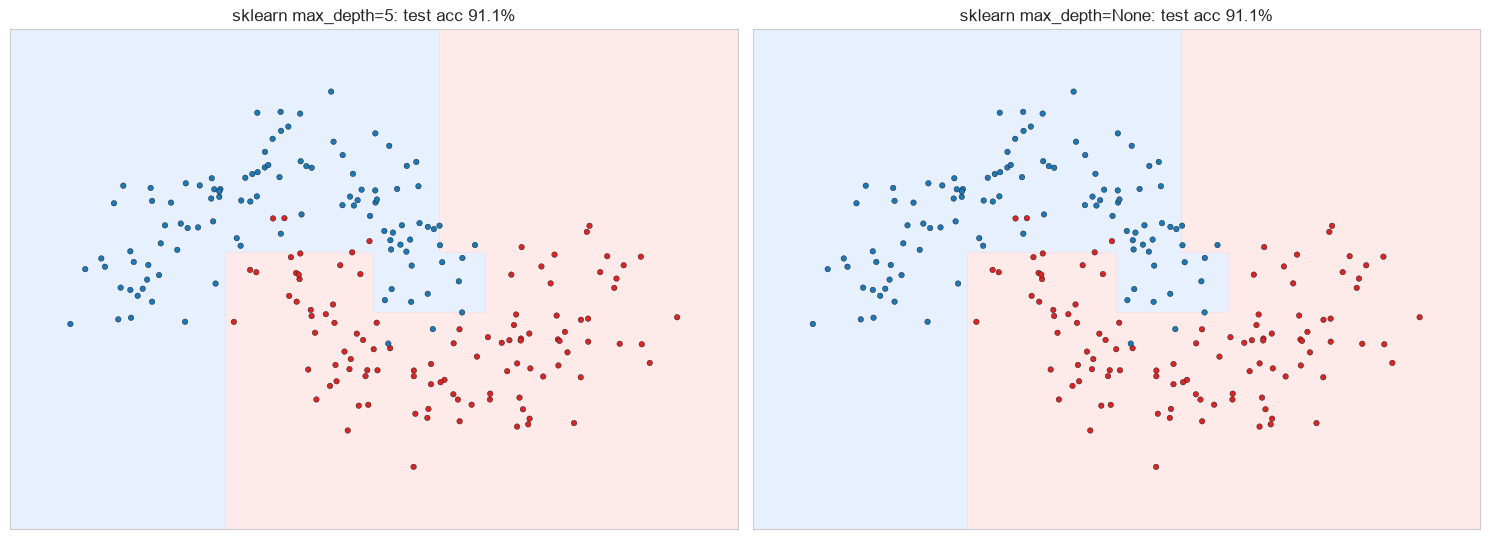

💡 The unconstrained tree buys train accuracy and sells test accuracy — the partition
   develops thin islands around noise. This is §5 instability made visible in one fit.


In [13]:
# Same moons, same hyperparameters as the scratch fit — scikit-learn engine
tree_sk5 = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                  criterion='gini', random_state=42).fit(Xm_tr, ym_tr)
tree_skfull = DecisionTreeClassifier(min_samples_leaf=5, criterion='gini',
                                     random_state=42).fit(Xm_tr, ym_tr)   # max_depth=None!

pred_sk = tree_sk5.predict(Xm_te)
print('=' * 60)
print('DECISION TREE CLASSIFIER (SCIKIT-LEARN)')
print('=' * 60)
print(f'  Accuracy:  {accuracy_score(ym_te, pred_sk):.4f}')
print(f'  Precision: {precision_score(ym_te, pred_sk):.4f}')
print(f'  Recall:    {recall_score(ym_te, pred_sk):.4f}')
print(f'  F1-Score:  {f1_score(ym_te, pred_sk):.4f}')

rows_sk = []
for name, m in [('max_depth=5', tree_sk5), ('max_depth=None', tree_skfull)]:
    rows_sk.append({'model': name,
                    'train acc': m.score(Xm_tr, ym_tr),
                    'test acc': m.score(Xm_te, ym_te),
                    'depth': m.get_depth(),
                    'leaves': m.get_n_leaves(),
                    'total nodes': m.tree_.node_count})
print()
print('🌳 Depth-5 vs unconstrained on the same data:')
print(pd.DataFrame(rows_sk).to_string(index=False, float_format=lambda v: f'{v:.4f}'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
region_panel(axes[0], tree_sk5, Xm_tr, ym_tr,
             f'sklearn max_depth=5: test acc {tree_sk5.score(Xm_te, ym_te):.1%}')
region_panel(axes[1], tree_skfull, Xm_tr, ym_tr,
             f'sklearn max_depth=None: test acc {tree_skfull.score(Xm_te, ym_te):.1%}')
plt.tight_layout()
plt.show()

print('💡 The unconstrained tree buys train accuracy and sells test accuracy — the partition')
print('   develops thin islands around noise. This is §5 instability made visible in one fit.')

### Dual Engine: Scratch vs Scikit-learn on the Same Data

Both engines run the same greedy rule — maximize impurity reduction with `x[f] <= τ` cuts — on the
same rows with the same limits. They should therefore build **near-identical trees**. They will
not be bit-identical, and the reason is worth knowing: ties. Multiple (feature, threshold)
candidates can achieve the exact same gain (§2's table showed a tie), and the two implementations
break ties differently (the twin takes the first in scan order; sklearn scans sorted values with
normalized impurity accounting). Identical greedy logic, occasionally different tie winners.

In [14]:
# tree_gini_s from §5 is the scratch engine (same data, same hyperparameters)
t0 = time.perf_counter()
sk_engine = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                   criterion='gini', random_state=42).fit(Xm_tr, ym_tr)
t_sk = time.perf_counter() - t0
# scratch timing: tree_gini_s was fitted in §5 — time a refit for a fair clock
t0 = time.perf_counter()
DecisionTreeClassifierScratch(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                              criterion='gini').fit(Xm_tr, ym_tr)
t_scr = time.perf_counter() - t0

pred_scr_d = tree_gini_s.predict(Xm_te)
pred_sk_d = sk_engine.predict(Xm_te)

print('=' * 60)
print('DUAL ENGINE: SCRATCH vs SCIKIT-LEARN (gini, same data, same limits)')
print('=' * 60)
print(f'| {"Metric":<28s} | {"Scratch":>12s} | {"Scikit-learn":>12s} |')
print('|' + '-' * 30 + '|' + '-' * 14 + '|' + '-' * 14 + '|')
print(f'| {"test accuracy":<28s} | {accuracy_score(ym_te, pred_scr_d):12.4f} | {accuracy_score(ym_te, pred_sk_d):12.4f} |')
print(f'| {"depth":<28s} | {tree_gini_s.get_depth():12d} | {sk_engine.get_depth():12d} |')
print(f'| {"nodes":<28s} | {tree_gini_s.count_nodes():12d} | {sk_engine.tree_.node_count:12d} |')
print(f'| {"fit time (s)":<28s} | {t_scr:12.3f} | {t_sk:12.3f} |')
print()
print(f'Prediction agreement on test rows: {np.mean(pred_scr_d == pred_sk_d):.1%}')
print()
print('💡 Same objective, same cut rule, same limits → near-identical trees; residual')
print('   disagreement is tie-breaking, not different math. The wall-clock gap is the C code.')

DUAL ENGINE: SCRATCH vs SCIKIT-LEARN (gini, same data, same limits)
| Metric                       |      Scratch | Scikit-learn |
|------------------------------|--------------|--------------|
| test accuracy                |       0.9000 |       0.9111 |
| depth                        |            5 |            5 |
| nodes                        |           23 |           23 |
| fit time (s)                 |        0.044 |        0.001 |

Prediction agreement on test rows: 98.9%

💡 Same objective, same cut rule, same limits → near-identical trees; residual
   disagreement is tie-breaking, not different math. The wall-clock gap is the C code.


### Reading a Full Tree: the Iris Classic

At 150 rows and 4 features, iris can be drawn **whole** — every node, every leaf — which is the
payoff of choosing a tree for interpretability. Fit a small tree and read it like a flowchart;
the printed legend decodes each box.

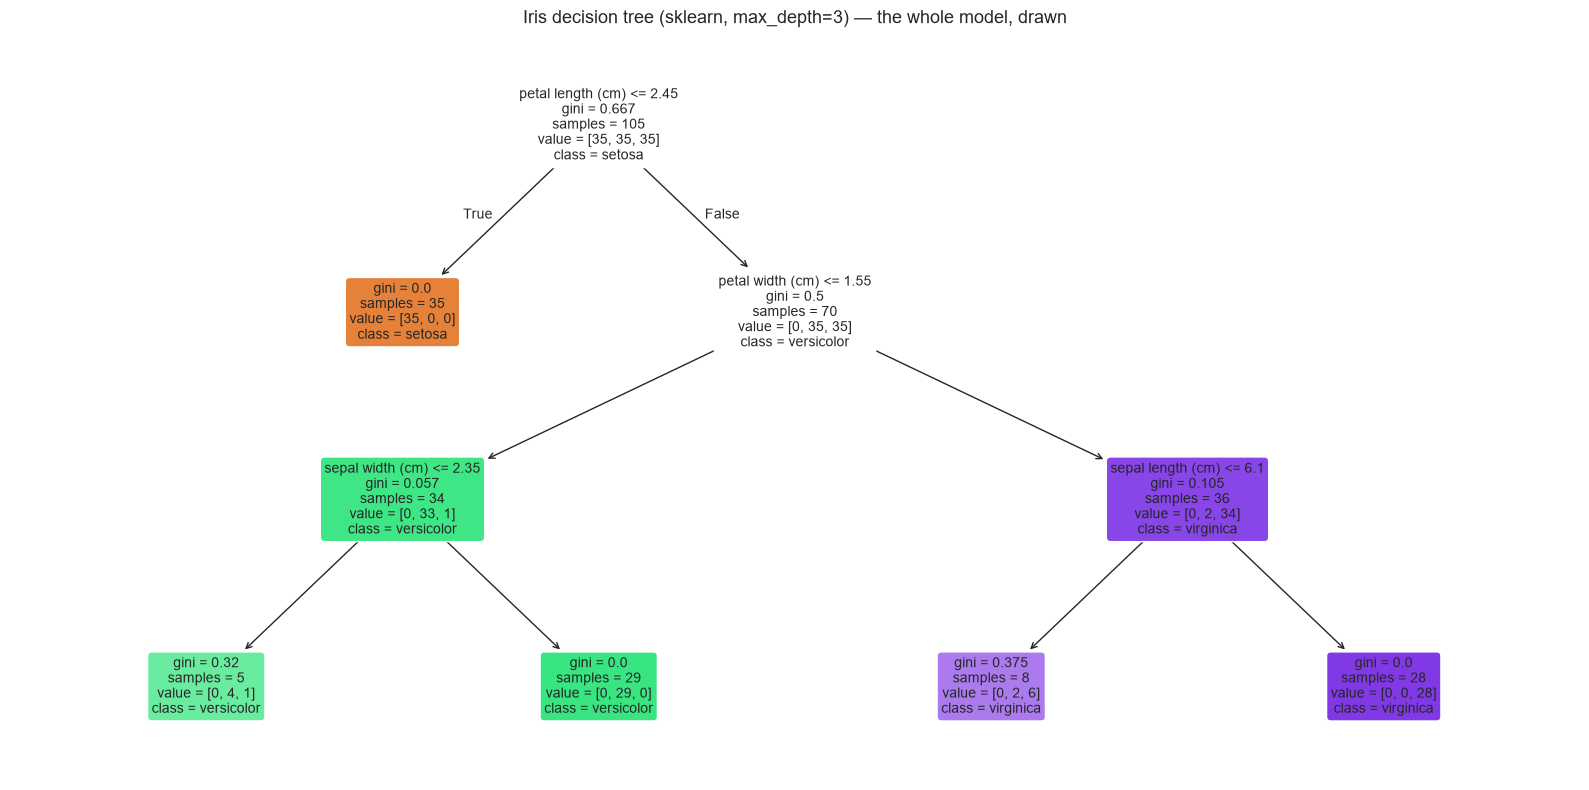

TEST ACCURACY: 0.8889 on 3 classes, one tree

📖 How to read every box:
  • top line       = the split rule (petal length (cm) <= 2.45 → True = left, False = right)
  • gini           = node impurity (§2): 0 = pure, higher = mixed
  • samples        = training rows that reached this node
  • value          = [setosa, versicolor, virginica] counts at the node
  • class / colour = the majority class this node currently predicts
🔍 Feature importances (impurity reduction credited per feature):
          feature  importance
petal length (cm)    0.535168
 petal width (cm)    0.447722
sepal length (cm)    0.011893
 sepal width (cm)    0.005217

⚙️ sklearn extras on the first 3 test rows:
  • .apply(X) → leaf index each row lands in: [8 5 5]
  • .decision_path(X) → sparse path matrix; first row activates 4 nodes

💡 Petal features carry almost the entire tree (sepal features ~0): the greedy search
   found early petal splits that made sepal splits redundant. Importance, not guesswork.


In [15]:
iris = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(iris.data, iris.target, test_size=0.3,
                                              stratify=iris.target, random_state=42)

tree_iris = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42).fit(Xi_tr, yi_tr)

plt.figure(figsize=(16, 8))
plot_tree(tree_iris, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title('Iris decision tree (sklearn, max_depth=3) — the whole model, drawn', fontsize=13)
plt.tight_layout()
plt.show()

print('=' * 60)
print(f'TEST ACCURACY: {accuracy_score(yi_te, tree_iris.predict(Xi_te)):.4f} on 3 classes, one tree')
print('=' * 60)
print()
print('📖 How to read every box:')
print('  • top line       = the split rule (petal length (cm) <= 2.45 → True = left, False = right)')
print('  • gini           = node impurity (§2): 0 = pure, higher = mixed')
print('  • samples        = training rows that reached this node')
print('  • value          = [setosa, versicolor, virginica] counts at the node')
print('  • class / colour = the majority class this node currently predicts')

importance_iris = pd.DataFrame({'feature': iris.feature_names,
                                'importance': tree_iris.feature_importances_}
                               ).sort_values('importance', ascending=False)
print('🔍 Feature importances (impurity reduction credited per feature):')
print(importance_iris.to_string(index=False))

leaf_ids_iris = tree_iris.apply(Xi_te[:3])
paths_iris = tree_iris.decision_path(Xi_te[:1])
print()
print('⚙️ sklearn extras on the first 3 test rows:')
print(f'  • .apply(X) → leaf index each row lands in: {leaf_ids_iris}')
print(f'  • .decision_path(X) → sparse path matrix; first row activates {paths_iris[0].sum()} nodes')
print()
print('💡 Petal features carry almost the entire tree (sepal features ~0): the greedy search')
print('   found early petal splits that made sepal splits redundant. Importance, not guesswork.')

---

## 7. Hyperparameter Tuning

Three rules govern this section — same rules as notebook 05:

1. Choose with **cross-validation on training data only**; the test set is touched once, at the end
2. Study **one lever at a time** first (depth, then leaf size), then a small joint grid
3. Complexity knobs act together: deeper trees want larger `min_samples_leaf`, and pruning is the
   honest alternative to capping depth by hand

The levers, in the order that matters:

- **`max_depth`** — the resolution of the staircase (§2)
- **`min_samples_leaf`** — the smallest reliable sample a leaf may stand on (§3, assumption 3)
- **`ccp_alpha`** — cost-complexity pruning: grow freely, then cut back what does not pay (below)

Tuning data: a noisier moons set (400 rows, noise 0.3), so there is real noise to overfit —
the same setup notebook 05 used to tune C and gamma.

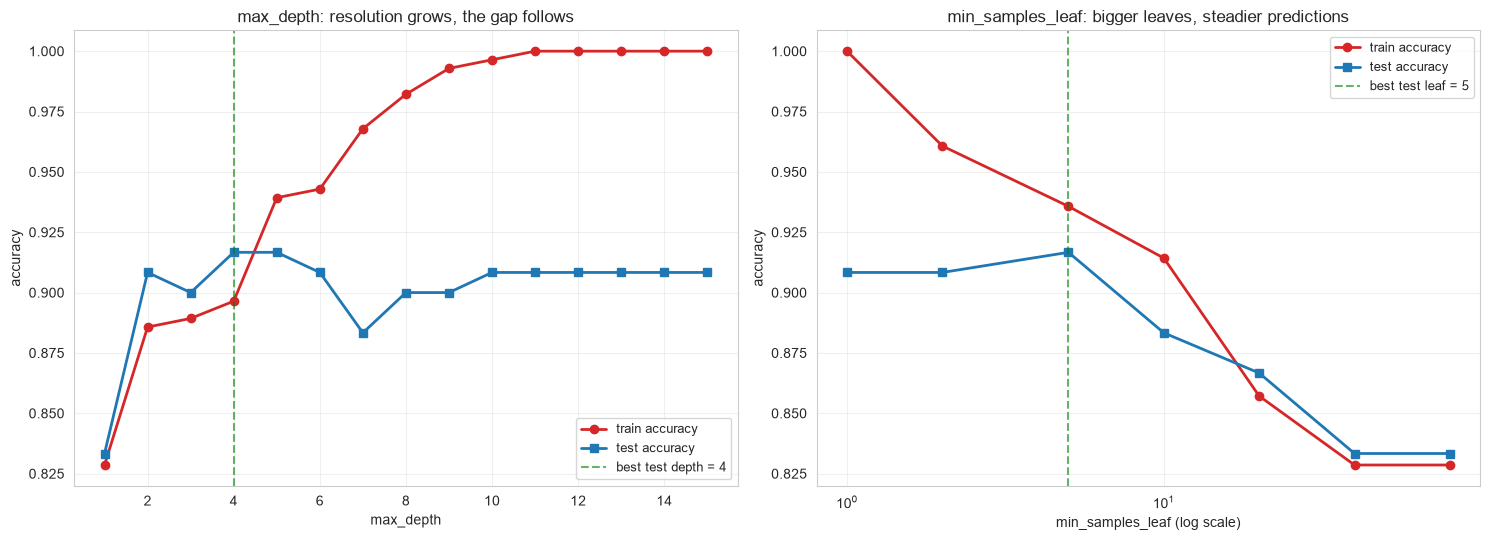

max_depth sweep:        train 1.0000 → test 0.9083 at depth 15; best test 0.9167 at depth 4
min_samples_leaf sweep: best test 0.9167 at 5 samples/leaf

💡 Left panel: train accuracy climbs monotonically toward 1.0 while test accuracy peaks
   early and sags — the overfit signature, in one picture. Right panel: forcing bigger
   leaves trades a little training fit for stability. Choose both from CV, never from
   these test curves — the test set gets one final report, at the end.


In [16]:
# One lever at a time: max_depth and min_samples_leaf sweeps (train-only curves vs test)
X_tune, y_tune = make_moons(n_samples=400, noise=0.3, random_state=3)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_tune, y_tune, test_size=0.3,
                                              stratify=y_tune, random_state=42)

depth_range = list(range(1, 16))
tr_d, te_d = [], []
for d in depth_range:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xt_tr, yt_tr)
    tr_d.append(m.score(Xt_tr, yt_tr))
    te_d.append(m.score(Xt_te, yt_te))

leaf_range = [1, 2, 5, 10, 20, 40, 80]
tr_l, te_l = [], []
for n_leaf in leaf_range:
    m = DecisionTreeClassifier(min_samples_leaf=n_leaf, random_state=42).fit(Xt_tr, yt_tr)
    tr_l.append(m.score(Xt_tr, yt_tr))
    te_l.append(m.score(Xt_te, yt_te))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(depth_range, tr_d, 'o-', color='#d62728', lw=2, label='train accuracy')
axes[0].plot(depth_range, te_d, 's-', color='#1f77b4', lw=2, label='test accuracy')
axes[0].axvline(int(np.argmax(te_d)) + 1, color='green', ls='--', alpha=0.6,
                label=f'best test depth = {int(np.argmax(te_d)) + 1}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('accuracy')
axes[0].set_title('max_depth: resolution grows, the gap follows')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(leaf_range, tr_l, 'o-', color='#d62728', lw=2, label='train accuracy')
axes[1].semilogx(leaf_range, te_l, 's-', color='#1f77b4', lw=2, label='test accuracy')
best_leaf = leaf_range[int(np.argmax(te_l))]
axes[1].axvline(best_leaf, color='green', ls='--', alpha=0.6, label=f'best test leaf = {best_leaf}')
axes[1].set_xlabel('min_samples_leaf (log scale)')
axes[1].set_ylabel('accuracy')
axes[1].set_title('min_samples_leaf: bigger leaves, steadier predictions')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'max_depth sweep:        train {tr_d[-1]:.4f} → test {te_d[-1]:.4f} at depth 15; '
      f'best test {max(te_d):.4f} at depth {int(np.argmax(te_d)) + 1}')
print(f'min_samples_leaf sweep: best test {max(te_l):.4f} at {best_leaf} samples/leaf')
print()
print('💡 Left panel: train accuracy climbs monotonically toward 1.0 while test accuracy peaks')
print('   early and sags — the overfit signature, in one picture. Right panel: forcing bigger')
print('   leaves trades a little training fit for stability. Choose both from CV, never from')
print('   these test curves — the test set gets one final report, at the end.')

### Cost-Complexity Pruning: the `ccp_alpha` Story

Pruning is the tree's version of regularization — and sklearn makes it a two-act procedure:

1. `cost_complexity_pruning_path` grows an **unconstrained** tree and reports every α at which a
   subtree becomes worth cutting: the **effective alphas**. The trade is one number:
   $R_\alpha(T) = R(T) + \alpha \cdot |\text{leaves}(T)|$ — training error plus α per leaf
2. Cross-validate α (it is a hyperparameter like any other), refit with the winner

Small α → almost no pruning (the overfit tree). Large α → the whole tree collapses toward a
stump. The best α lives in between, where test accuracy peaks at a fraction of the leaves.

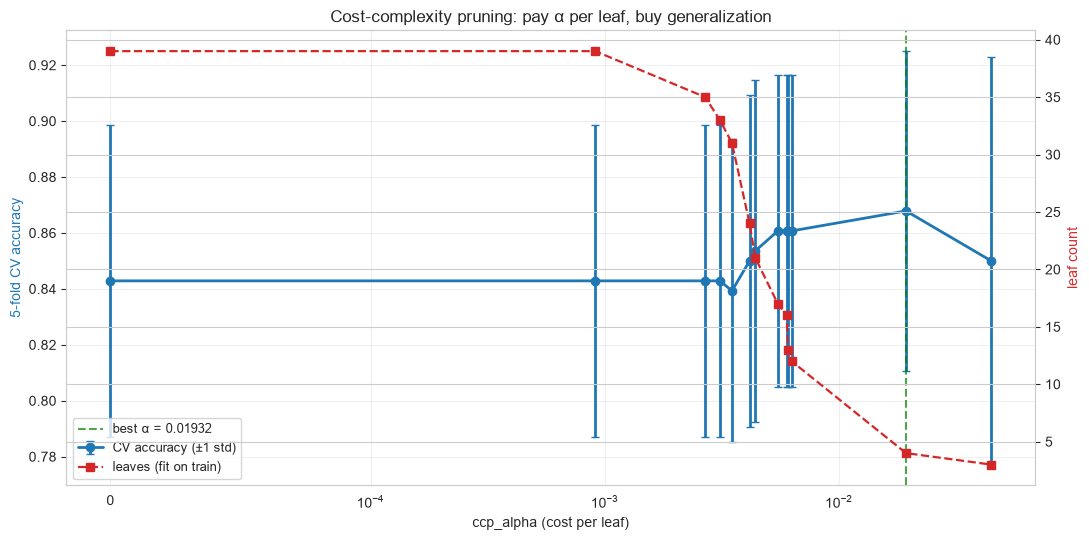

Unconstrained tree: leaves 39, test acc 0.9083
Pruned (α = 0.01932): leaves 4, test acc 0.9083

💡 Read the two panels together (the 05 trick): accuracy holds or improves while the
   leaf count collapses — the cut subtrees were memorizing noise, not structure.
   The scratch twin has no pruning: this lever is sklearn-side only (§8 coverage table).


In [17]:
# Act 1: the effective-alpha path of an unconstrained tree, cross-validated
path_t = DecisionTreeClassifier(random_state=42).fit(Xt_tr, yt_tr).cost_complexity_pruning_path(Xt_tr, yt_tr)
ccp_path = path_t.ccp_alphas                      # ascending; last entry = stump
alphas_grid = np.unique(np.round(np.concatenate(
    [[0.0], np.quantile(ccp_path[:-1], np.linspace(0.02, 0.98, 12))]), 5))

cvfold_p = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_mean_p, cv_std_p, leaves_p = [], [], []
for a_p in alphas_grid:
    scores_p = cross_val_score(DecisionTreeClassifier(ccp_alpha=a_p, random_state=42),
                               Xt_tr, yt_tr, cv=cvfold_p, scoring='accuracy', n_jobs=-1)
    cv_mean_p.append(scores_p.mean())
    cv_std_p.append(scores_p.std())
    leaves_p.append(DecisionTreeClassifier(ccp_alpha=a_p,
                                           random_state=42).fit(Xt_tr, yt_tr).get_n_leaves())

best_alpha = float(alphas_grid[int(np.argmax(cv_mean_p))])

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.errorbar(alphas_grid, cv_mean_p, yerr=cv_std_p, marker='o', color='#1f77b4', lw=2,
             capsize=3, label='CV accuracy (±1 std)')
ax1.axvline(best_alpha, color='green', ls='--', alpha=0.7, label=f'best α = {best_alpha:.4g}')
ax1.set_xscale('symlog', linthresh=1e-4)
ax1.set_xlabel('ccp_alpha (cost per leaf)')
ax1.set_ylabel('5-fold CV accuracy', color='#1f77b4')
ax2 = ax1.twinx()
ax2.plot(alphas_grid, leaves_p, 's--', color='#d62728', lw=1.6, label='leaves (fit on train)')
ax2.set_ylabel('leaf count', color='#d62728')
ax1.set_title('Cost-complexity pruning: pay α per leaf, buy generalization')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='lower left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Act 2: refit with the CV winner and give the test set its one report
unpruned_t = DecisionTreeClassifier(random_state=42).fit(Xt_tr, yt_tr)
pruned_t = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42).fit(Xt_tr, yt_tr)

print(f'Unconstrained tree: leaves {unpruned_t.get_n_leaves()}, '
      f'test acc {unpruned_t.score(Xt_te, yt_te):.4f}')
print(f'Pruned (α = {best_alpha:.4g}): leaves {pruned_t.get_n_leaves()}, '
      f'test acc {pruned_t.score(Xt_te, yt_te):.4f}')
print()
print('💡 Read the two panels together (the 05 trick): accuracy holds or improves while the')
print('   leaf count collapses — the cut subtrees were memorizing noise, not structure.')
print('   The scratch twin has no pruning: this lever is sklearn-side only (§8 coverage table).')

### The Joint Grid: `max_depth` × `min_samples_leaf`

One knob at a time says where the cliff is; the joint grid says where the plateau is. Same
protocol as notebook 05's (C, γ) heatmap: stratified 5-fold CV, training data only, then a single
test-set report.

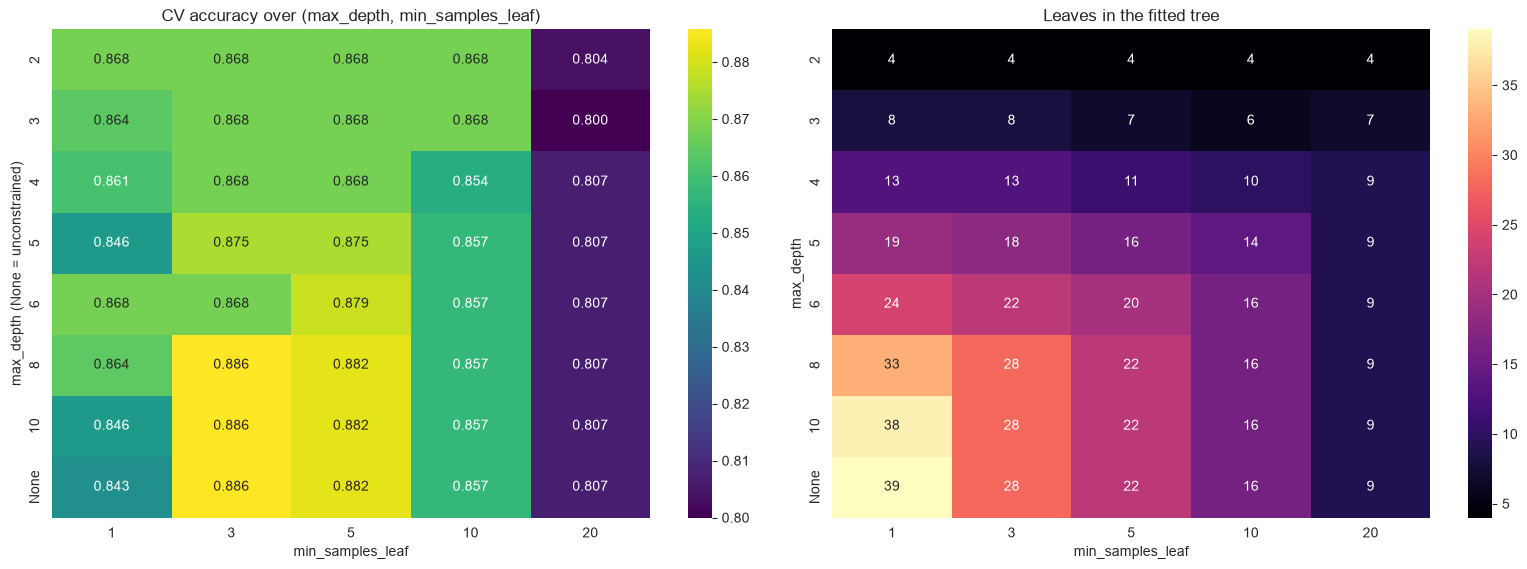

✨ Best parameters: {'max_depth': 8, 'min_samples_leaf': 3}
✨ Best CV accuracy: 0.8857
📊 Held-out test accuracy with the best model: 0.9333

💡 The accuracy plateau is wide (several combinations within noise of the best) while
   the leaf-count panel varies 10×. When CV cannot separate them, prefer the smaller tree —
   it is the same decision the pruning curve made, made manually.


In [18]:
depth_grid_t = [2, 3, 4, 5, 6, 8, 10, None]
leaf_grid_t = [1, 3, 5, 10, 20]
grid_tune = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': depth_grid_t, 'min_samples_leaf': leaf_grid_t},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
)
grid_tune.fit(Xt_tr, yt_tr)

cv_df_t = pd.DataFrame(grid_tune.cv_results_)
cv_df_t['depth label'] = [('None' if d is None else str(d)) for d in cv_df_t['param_max_depth']]
cv_table_t = (cv_df_t.pivot_table(values='mean_test_score', index='depth label',
               columns='param_min_samples_leaf').reindex(index=[str(d) for d in depth_grid_t]))

# companion matrix: how big does each combination's tree get on the training split?
leaf_mat_t = np.zeros((len(depth_grid_t), len(leaf_grid_t)), dtype=int)
for i_d, d_val in enumerate(depth_grid_t):
    for j_l, l_val in enumerate(leaf_grid_t):
        leaf_mat_t[i_d, j_l] = DecisionTreeClassifier(max_depth=d_val, min_samples_leaf=l_val,
                                                      random_state=42).fit(Xt_tr, yt_tr).get_n_leaves()
leaf_table_t = pd.DataFrame(leaf_mat_t, index=[str(d) for d in depth_grid_t], columns=leaf_grid_t)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.8))
sns.heatmap(cv_table_t, annot=True, fmt='.3f', cmap='viridis', ax=axes[0],
            yticklabels=[str(d) for d in cv_table_t.index],
            xticklabels=[str(l) for l in cv_table_t.columns])
axes[0].set_title('CV accuracy over (max_depth, min_samples_leaf)')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_ylabel('max_depth (None = unconstrained)')
sns.heatmap(leaf_table_t, annot=True, fmt='d', cmap='magma', ax=axes[1])
axes[1].set_title('Leaves in the fitted tree')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('max_depth')
plt.tight_layout()
plt.show()

print(f'✨ Best parameters: {grid_tune.best_params_}')
print(f'✨ Best CV accuracy: {grid_tune.best_score_:.4f}')
print(f'📊 Held-out test accuracy with the best model: {grid_tune.score(Xt_te, yt_te):.4f}')
print()
print('💡 The accuracy plateau is wide (several combinations within noise of the best) while')
print('   the leaf-count panel varies 10×. When CV cannot separate them, prefer the smaller tree —')
print('   it is the same decision the pruning curve made, made manually.')

---

## 8. Complete Hyperparameter Reference

### DecisionTreeClassifier Parameters (scikit-learn 1.9)

#### `max_depth` (int or None, default=None) **[THE HYPERPARAMETER]**
- **Description**: depth cap on the recursion. `None` grows until every leaf is pure (or too small
  to split) — the overfit default
- **Effect**: the resolution of the staircase (§2). Small → underfits smooth structure; large →
  memorizes noise (the §7 sweep showed both)
- **Tuning strategy**: the §7 sweep + the joint grid; or skip the cap and prune with `ccp_alpha`
- **Note**: the scratch twin defaults to 10, not `None`
- **Example**: `DecisionTreeClassifier(max_depth=5)`

#### `min_samples_leaf` (int or float, default=1) **[SECOND LEVER]**
- **Description**: smallest sample count (or fraction) a leaf may hold; enforced during the split
  search — a candidate that would orphan a too-small child is never even scored
- **Effect**: leaf predictions stand on more evidence; the boundary smooths
- **Tuning strategy**: [1, 3, 5, 10, 20] on a few hundred rows, log-spaced on larger data
- **Example**: `DecisionTreeClassifier(min_samples_leaf=5)`

#### `min_samples_split` (int or float, default=2)
- **Description**: smallest node size that may still attempt a split
- **Effect**: similar direction as `min_samples_leaf` (coarser trees), one level earlier. In
  practice tune `min_samples_leaf` first — it guarantees leaf quality directly
- **Example**: `DecisionTreeClassifier(min_samples_split=20)`

#### `criterion` (str, default='gini')
- **Classification options**: `'gini'` (default, no log), `'entropy'` (ID3/C4.5 flavor),
  `'log_loss'` (equivalent to entropy for split search)
- **Regression options**: `'squared_error'` (default), `'absolute_error'` (robust to outliers,
  slower), `'friedman_mse'` (gradient-boosting's modification), `'poisson'` (count targets)
- **Effect**: near-interchangeable for classification (§5 measured the agreement); regression
  criteria genuinely change the tree
- **Example**: `DecisionTreeRegressor(criterion='absolute_error')`

#### `ccp_alpha` (float, default=0.0) **[THE PRUNING LEVER]**
- **Description**: cost per leaf in $R_\alpha(T) = R(T) + \alpha \cdot |\text{leaves}|$; subtrees
  whose impurity drop does not pay their α are cut
- **Effect**: the §7 curve — fewer leaves, equal-or-better test accuracy, often the cleanest
  control over tree size
- **Tuning strategy**: read `cost_complexity_pruning_path`, CV the alphas (§7)
- **Example**: `DecisionTreeClassifier(ccp_alpha=0.01)`

#### `splitter` (str, default='best')
- **Options**: `'best'` (full scan), `'random'` (best of random candidates per node)
- **When**: `'random'` adds per-tree diversity — an ingredient of forests, not of single trees
- **Example**: `DecisionTreeClassifier(splitter='random')`

#### `max_features` (int/float/str, default=None)
- **Description**: feature subsample per split search (`'sqrt'`, `'log2'`, fraction)
- **Effect**: de-correlates trees across nodes — an ensemble ingredient; on a single tree it just
  risks missing the best split
- **Example**: `DecisionTreeClassifier(max_features='sqrt')` (then see notebook 04)

#### `max_leaf_nodes` (int or None, default=None)
- **Description**: hard cap on leaf count — grow greedily in impurity-decrease order, stop at the cap
- **Effect**: a size budget stated directly; alternative to depth
- **Example**: `DecisionTreeClassifier(max_leaf_nodes=12)`

#### `min_impurity_decrease` (float, default=0.0)
- **Description**: a split must reduce impurity by at least this (weighted by reached samples)
- **Effect**: pre-growth pruning, cousin of `ccp_alpha`
- **Example**: `DecisionTreeClassifier(min_impurity_decrease=0.01)`

#### `class_weight` (dict, 'balanced', or None, default=None) **[classification]**
- **Description**: per-class impurity weighting. `'balanced'` = inverse-frequency
- **Effect**: rare classes become expensive to misroute; the tree splits earlier for them
- **Caveat**: trades overall accuracy for the minority class — pick by the error cost
- **Example**: `DecisionTreeClassifier(class_weight='balanced')`

#### `random_state` (int, default=None)
- **Description**: seeds feature shuffling and random splits; with defaults (`splitter='best'`,
  `max_features=None`) the fit is deterministic anyway. Pin it for reproducibility
- **Example**: `DecisionTreeClassifier(random_state=42)`

### Scratch Twin Coverage

| scikit-learn parameter | Scratch twin | Notes |
|---|---|---|
| `max_depth` | ✅ | default 10 vs sklearn's None |
| `min_samples_split` | ✅ | same meaning, default 2 |
| `min_samples_leaf` | ✅ | enforced during split search, like sklearn |
| `criterion` | ✅ `'gini'`, `'entropy'` | no `'log_loss'`; regressor is MSE-only |
| `ccp_alpha` | ❌ | no post-pruning; limits apply while growing |
| `splitter` | ❌ | exhaustive `'best'` scan always |
| `max_features` | ❌ | all features scanned at every node |
| `max_leaf_nodes`, `min_impurity_decrease` | ❌ | the four §5 stopping rules only |
| `class_weight` | ❌ | not implemented |
| `random_state` | n/a | nothing in the training path is random |
| multi-class labels | ✅ | any sortable labels; remapped internally (fact 4, §5) |
| `predict_proba` | ✅ | exact leaf fractions, verified against `tests/models/test_tree_models.py` |
| SVR (regressor twin) | ✅ | variance-reduction splits, mean leaves, `apply()` for boosting |

### Parameter Combination Recipes

#### Baseline (always start here):
```python
DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
```

#### Anti-overfit (noisy data):
```python
DecisionTreeClassifier(max_depth=7, min_samples_leaf=10, random_state=42)
```

#### The pruning route (often better than a depth cap):
```python
tree = DecisionTreeClassifier(random_state=42)   # grow freely...
path = tree.cost_complexity_pruning_path(X_tr, y_tr)   # ...then CV ccp_alpha (§7)
```

#### Imbalanced classes:
```python
DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, class_weight='balanced', random_state=42)
```

#### Regression:
```python
DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42)
```

#### Ensemble-ready (what notebook 04 builds on):
```python
DecisionTreeClassifier(max_features='sqrt', splitter='random', random_state=None)
```

---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **Never Ship an Unconstrained Tree**
`max_depth=None` grows until pure. On real data with noise, that is memorization by construction.
```python
tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
```
---
#### 2. **Prefer Pruning to Hand-Capping When It Matters**
The α path finds the cut sklearn's greedy growth wishes it had made earlier.
```python
path = tree.cost_complexity_pruning_path(X_train, y_train)   # effective alphas, then CV (§7)
```
---
#### 3. **Measure Overfitting as a Gap, Not a Feeling**
```python
train_acc, test_acc = tree.score(X_train, y_train), tree.score(X_test, y_test)
if train_acc - test_acc > 0.10:   # shrink: depth down, leaves up, or prune
    ...
```
---
#### 4. **No Scaling — Spend the Effort Elsewhere**
The preprocessing budget goes to missing values and encodings, not to `StandardScaler` (§3).
---
#### 5. **Read Importances with Suspicion**
Tree importances are impurity-reduction credits: features with more split points (continuous,
high-cardinality) get more chances to win credit. Cross-check with `permutation_importance`
(§10 Example 1 does exactly this).
---
#### 6. **Imbalance: Weight or Threshold, Know Which**
`class_weight='balanced'` changes where splits happen; moving the predict threshold afterwards
changes decisions without retraining. Both are legitimate — decide by the cost of each error type.
---
#### 7. **Extract the Rules for the Stakeholders**
`export_text(tree, feature_names=...)` turns the model into reviewable rules (§10 Example 1);
`decision_path` pins exactly which rules fired for one row.
---
#### 8. **One Tree Explains, an Ensemble Predicts**
If accuracy is the deliverable, a single tree is a stepping stone: notebook 04 (bagging),
08 (boosting), 09–11 (libraries). §11 quantifies the gap.

### ❌ Common Mistakes

#### 1. **`DecisionTreeClassifier()` with no arguments, on real data**
Train accuracy 1.00, test accuracy visibly lower — the §7 sweep's right-hand side, self-inflicted.
---
#### 2. **Trusting a Single Tree's `predict_proba`**
Probabilities are leaf fractions: on a 100-leaf tree they take only as many distinct values as
leaves hold, and confident 1.0s are common even where the model is shaky (§10 histogram).
Smooth them with an ensemble or calibrate (notebook 05 §10 for the machinery).
---
#### 3. **Asking the Tree to Extrapolate**
New x outside the training range → clamped leaf value, silently (§10 Example 2 shows the plateau).
Use linear models when trend is the signal.
---
#### 4. **Ignoring Feature-Importance Bias**
A categorical ID column with 1,000 levels can dominate importances while adding no real signal.
Drop identifiers, then compare with permutation importance.
---
#### 5. **One-Hotting High-Cardinality Categoricals for a Tree**
One-hot scatters a single feature's signal across many sparse columns; greedy per-column splits
then pick it up in fragments. Ordinal-encode for trees (they only need order-compatible splits),
or use a library that handles categoricals natively (CatBoost, notebook 11).
---
#### 6. **Diagnosing Instability as a Bug**
Fitting twice with a reshuffled train set and getting a different tree is not a bug — it is the
§5 result. Aggregate it (forest) or accept it (interpretation-focused small tree).

### Debugging Recipes

#### Tree Predicts (Almost) One Class?
1. Impurity weighting: with `class_weight='balanced'` and heavy imbalance, deep pure-minority
   leaves can dominate regions — check the leaf fractions
2. Labels scrambled after encoding — `classes_` shows what the model actually learned
3. Target leakage making training trivial — check features derived from the label

#### Train ≈ 1.0, Test Noticeably Lower?
1. Depth/leaf sweep (§7) — find the knee
2. Prune with the α path (§7)
3. More data helps trees directly (they refine partitions instead of moving coefficients)

#### Tree Way Too Large to Read?
1. `max_leaf_nodes=12` + `max_depth=5` for a presentable model
2. `plot_tree(max_depth=2)` to show the skeleton, full tree in text (`export_text`)
3. If the rules are still nonsense, the features probably are too

#### Accuracy Stuck Low on Both Train and Test?
1. Underfitting: raise depth, lower `min_samples_leaf`
2. Check the geometry: heavily rotated classes fight axis-aligned cuts (§3) — whiten features
3. Check for label noise: unreachable accuracy is a data property, not a hyperparameter one

#### The Scratch Twin Is Slow?
1. Its split scan is $O(n \cdot m \cdot u)$ per node — keep demos ≤ a few hundred rows
2. `min_samples_leaf ≥ 5` prunes the recursion early and speeds the build
3. Above ~1,000 rows: use sklearn — the twin is for understanding, not throughput

---

## 10. Real-world Examples

Two examples chosen as a **pair of contrasts**, both bundled with scikit-learn (no downloads):

- **Example 1: Breast Cancer Diagnosis (binary, medical).** Interpretability is the *product*:
  the workflow is a no-scaler pipeline (§3), CV tuning, per-class reporting where missed
  malignancies are the headline, and a full audit of the rules one tumor actually triggered.
- **Example 2: Diabetes Progression (regression, 442 patients).** The staircase in the wild:
  shallow vs deep vs CV-tuned trees on a real target, leaf-mean predictions on the most
  important feature, and the extrapolation clamp demonstrated on purpose.

The scratch twin is sized for few-hundred-row fits and would manage both datasets, but §5 already
made its points; these sections run scikit-learn at full size, like notebooks 05 and 12.

### Example 1: Breast Cancer Diagnosis (Binary, Medical)

569 tumors, 30 numeric features, labels: malignant (0) / benign (1) — sklearn's convention, kept
here (summary metrics describe the benign positive class; the per-class report and the missed
counts are the clinically relevant numbers).

In [19]:
# Data + tuning: no scaler, CV on training rows only, test touched once
bc = load_breast_cancer()
Xb, yb = bc.data, bc.target
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.25,
                                              stratify=yb, random_state=42)

bc_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3, 4, 5, 6, 8, None], 'min_samples_leaf': [1, 5, 10, 20]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)
bc_grid.fit(Xb_tr, yb_tr)
tree_bc = bc_grid.best_estimator_

pred_bc = tree_bc.predict(Xb_te)
proba_bc = tree_bc.predict_proba(Xb_te)[:, 1]      # P(benign), quantized leaf fractions

print('=' * 60)
print('REAL-WORLD EXAMPLE: BREAST CANCER (DECISION TREE)')
print('=' * 60)
print()
print(f'📊 {Xb.shape[0]} tumors × {Xb.shape[1]} features')
print(f'   malignant (0): {np.sum(yb == 0)}   benign (1): {np.sum(yb == 1)}')
print(f'   Train/test: {len(yb_tr)} / {len(yb_te)} (stratified)')
print()
print(f'✨ Best parameters: {bc_grid.best_params_}')
print(f'✨ Best CV ROC-AUC: {bc_grid.best_score_:.4f}')

print('Test-set performance:')
print(f'  Accuracy: {accuracy_score(yb_te, pred_bc):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(yb_te, proba_bc):.4f}')
print('  Per-class report (the summary numbers above describe class 1 = benign):')
print(classification_report(yb_te, pred_bc, target_names=['malignant', 'benign']))

missed_bc = int(np.sum((yb_te == 0) & (pred_bc == 1)))
false_bc = int(np.sum((yb_te == 1) & (pred_bc == 0)))
print(f'Malignant tumors missed (false negatives): {missed_bc}')
print(f'Benign tumors flagged (false positives):   {false_bc}')

REAL-WORLD EXAMPLE: BREAST CANCER (DECISION TREE)

📊 569 tumors × 30 features
   malignant (0): 212   benign (1): 357
   Train/test: 426 / 143 (stratified)

✨ Best parameters: {'max_depth': 3, 'min_samples_leaf': 20}
✨ Best CV ROC-AUC: 0.9654
Test-set performance:
  Accuracy: 0.9161
  ROC-AUC:  0.9627
  Per-class report (the summary numbers above describe class 1 = benign):
              precision    recall  f1-score   support

   malignant       0.84      0.96      0.89        53
      benign       0.98      0.89      0.93        90

    accuracy                           0.92       143
   macro avg       0.91      0.93      0.91       143
weighted avg       0.92      0.92      0.92       143

Malignant tumors missed (false negatives): 2
Benign tumors flagged (false positives):   10


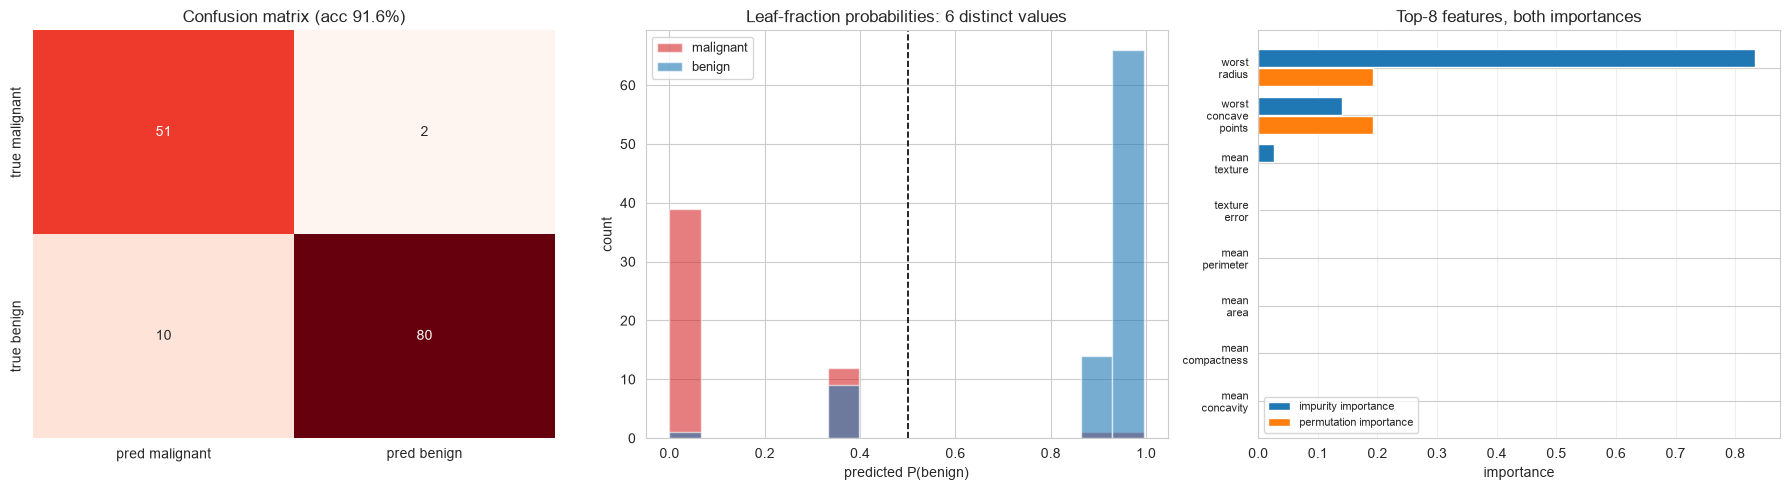

🔍 Top features (impurity credit vs held-out permutation score):
  worst radius                 impurity 0.8335   permutation 0.1930
  worst concave points         impurity 0.1400   permutation 0.1930
  mean texture                 impurity 0.0260   permutation 0.0000
  texture error                impurity 0.0005   permutation 0.0000
  mean perimeter               impurity 0.0000   permutation 0.0000

💡 Middle panel: probabilities come from leaf fractions — they take only as many
   distinct values as the tree has leaves, and 1.00s appear whenever a leaf is pure.
   Right panel: the two importance views broadly agree here; when they do not, trust
   permutation — impurity credit favors continuous, many-split-point features (§9).


In [20]:
# Reading the model: confusion, the blocky-probability lesson, importance cross-checked
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(yb_te, pred_bc), annot=True, fmt='d', cmap='Reds', cbar=False,
            ax=axes[0], xticklabels=['pred malignant', 'pred benign'],
            yticklabels=['true malignant', 'true benign'])
axes[0].set_title(f'Confusion matrix (acc {accuracy_score(yb_te, pred_bc):.1%})')

axes[1].hist(proba_bc[yb_te == 0], bins=15, alpha=0.6, color='#d62728', label='malignant')
axes[1].hist(proba_bc[yb_te == 1], bins=15, alpha=0.6, color='#1f77b4', label='benign')
axes[1].axvline(0.5, color='black', ls='--', lw=1.2)
axes[1].set_xlabel('predicted P(benign)')
axes[1].set_ylabel('count')
axes[1].set_title(f'Leaf-fraction probabilities: {len(np.unique(np.round(proba_bc, 6)))} distinct values')
axes[1].legend(fontsize=9)

imp_df = pd.DataFrame({'feature': bc.feature_names,
                       'impurity importance': tree_bc.feature_importances_})
perm_bc = permutation_importance(tree_bc, Xb_te, yb_te, n_repeats=15, random_state=42)
imp_df['permutation importance'] = perm_bc.importances_mean
imp_df = imp_df.sort_values('impurity importance', ascending=False).head(8)

y_pos = np.arange(len(imp_df))
axes[2].barh(y_pos - 0.2, imp_df['impurity importance'], height=0.38, color='#1f77b4',
             label='impurity importance')
axes[2].barh(y_pos + 0.2, imp_df['permutation importance'].clip(lower=0), height=0.38,
             color='#ff7f0e', label='permutation importance')
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels([f.replace(' ', chr(10)) for f in imp_df['feature']], fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('importance')
axes[2].set_title('Top-8 features, both importances')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('🔍 Top features (impurity credit vs held-out permutation score):')
for _, r in imp_df.head(5).iterrows():
    print(f'  {r["feature"]:<28s} impurity {r["impurity importance"]:.4f}   '
          f'permutation {max(0.0, r["permutation importance"]):.4f}')
print()
print('💡 Middle panel: probabilities come from leaf fractions — they take only as many')
print('   distinct values as the tree has leaves, and 1.00s appear whenever a leaf is pure.')
print('   Right panel: the two importance views broadly agree here; when they do not, trust')
print('   permutation — impurity credit favors continuous, many-split-point features (§9).')

In [21]:
# The interpretability payoff: the rules one tumor actually triggered
def path_rules(tree_sk, x_row, feature_names):
    # Walk sklearn's flat tree_ arrays for one row, collecting each rule as text.
    t = tree_sk.tree_
    node, rules = 0, []
    while t.children_left[node] != -1:          # -1 marks a leaf
        f_idx, thr = t.feature[node], t.threshold[node]
        go_left = x_row[f_idx] <= thr
        rules.append(f'{feature_names[f_idx]} = {x_row[f_idx]:>8.2f} '
                     f'{"<=" if go_left else " >"} {thr:.2f}  → {"left" if go_left else "right"}')
        node = t.children_left[node] if go_left else t.children_right[node]
    counts = t.value[node][0]
    return rules, counts / counts.sum()


target_bc = np.flatnonzero((yb_te == 0) & (pred_bc == 1))   # a missed malignancy, if any
fallback_bc = np.flatnonzero(yb_te == 0)
i_patient = int(target_bc[0]) if len(target_bc) else int(fallback_bc[0])

rules_patient, frac_patient = path_rules(tree_bc, Xb_te[i_patient], list(bc.feature_names))
pred_patient = tree_bc.predict(Xb_te[[i_patient]])[0]

print('=' * 60)
label_patient = 'MISSED MALIGNANCY' if len(target_bc) else 'MALIGNANT CASE'
print(f'AUDIT: {label_patient} — test row {i_patient}')
print('=' * 60)
print('Every rule this tumor triggered, from root to leaf:')
for step in rules_patient:
    print(f'  {step}')
print(f'🍃 Leaf class distribution: malignant {frac_patient[0]:.1%} / benign {frac_patient[1]:.1%}')
pred_word = 'malignant' if pred_patient == 0 else 'benign'
true_word = 'malignant' if yb_te[i_patient] == 0 else 'benign'
print(f'   Model call: {pred_word}   (true label: {true_word})')

compact_bc = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10,
                                    random_state=42).fit(Xb_tr, yb_tr)
print('📋 The stakeholder version — same idea, capped for a one-page read:')
print(export_text(compact_bc, feature_names=list(bc.feature_names)))
print('💡 This is why trees earn their place: the whole model is reviewable line by line.')
print('   A clinician can challenge any threshold above; no other model here offers that.')

AUDIT: MISSED MALIGNANCY — test row 4
Every rule this tumor triggered, from root to leaf:
  worst radius =    15.79 <= 16.80  → left
  worst concave points =     0.14 <= 0.14  → left
  mean texture =    23.29  > 21.56  → right
🍃 Leaf class distribution: malignant 7.1% / benign 92.9%
   Model call: benign   (true label: malignant)
📋 The stakeholder version — same idea, capped for a one-page read:
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 39.68
|   |   |   |--- class: 1
|   |   |--- area error >  39.68
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- class: 1
|   |   |--- worst texture >  25.62
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- mean texture <= 15.82
|   |   |--- class: 1
|   |--- mean texture >  15.82
|   |   |--- texture error <= 1.82
|   |   |   |--- class: 0
|   |   |--- texture error >  1.82
|   |   |   |--- class: 0

💡 This is why trees ea

### Example 2: Diabetes Progression (Regression, Real Patients)

442 patients, 10 baseline features, a continuous disease-progression score as the target. Three
trees on the same split: deliberately shallow, deliberately unconstrained, and one tuned by the
§7 grid recipe. The deep tree's train score will look great — the test column is where the truth
lives.

In [22]:
diab = load_diabetes()
Xdb, ydb = diab.data, diab.target
Xdb_tr, Xdb_te, ydb_tr, ydb_te = train_test_split(Xdb, ydb, test_size=0.25, random_state=42)

diab_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': [2, 3, 4, 5, 6, None], 'min_samples_leaf': [5, 10, 20]},
    cv=5,
    scoring='r2',
    n_jobs=-1,
)
diab_grid.fit(Xdb_tr, ydb_tr)
tree_db = diab_grid.best_estimator_

print('=' * 60)
print('REAL-WORLD EXAMPLE: DIABETES PROGRESSION (DECISION TREE REGRESSOR)')
print('=' * 60)
print()
print(f'📊 {Xdb.shape[0]} patients × {Xdb.shape[1]} features '
      f'(bundled set; features come pre-standardized)')
print(f'   Target: disease-progression score, range [{ydb.min():.0f}, {ydb.max():.0f}]')
print()
print(f'✨ Tuned parameters: {diab_grid.best_params_} (CV R² {diab_grid.best_score_:.4f})')

rows_db = []
for name, m in [('shallow (depth 3)', DecisionTreeRegressor(max_depth=3, min_samples_leaf=10,
                                                           random_state=42).fit(Xdb_tr, ydb_tr)),
                ('deep (max_depth=None)', DecisionTreeRegressor(random_state=42).fit(Xdb_tr, ydb_tr)),
                ('CV-tuned', tree_db)]:
    pred_db_tmp = m.predict(Xdb_te)
    rows_db.append({'tree': name,
                    'train R²': m.score(Xdb_tr, ydb_tr),
                    'test R²': r2_score(ydb_te, pred_db_tmp),
                    'test RMSE': np.sqrt(mean_squared_error(ydb_te, pred_db_tmp)),
                    'test MAE': mean_absolute_error(ydb_te, pred_db_tmp),
                    'leaves': m.get_n_leaves()})
db_df = pd.DataFrame(rows_db)
print('📈 Three trees, one split:')
print(db_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print()
print('💡 The deep tree trains to R² ≈ 1 by giving nearly every patient their own leaf, then')
print('   scores worse out-of-sample than the deliberately shallow one. The tuned tree lands')
print('   between: real signal captured, noise mostly refused. A single tree on this real')
print('   regression lands at a modest R² — honest, but far from what ensembles reach (nb 04).')

REAL-WORLD EXAMPLE: DIABETES PROGRESSION (DECISION TREE REGRESSOR)

📊 442 patients × 10 features (bundled set; features come pre-standardized)
   Target: disease-progression score, range [25, 346]

✨ Tuned parameters: {'max_depth': 2, 'min_samples_leaf': 20} (CV R² 0.3389)
📈 Three trees, one split:
                 tree  train R²  test R²  test RMSE  test MAE  leaves
    shallow (depth 3)    0.5063   0.4295    56.1647   44.4551       8
deep (max_depth=None)    1.0000  -0.0745    77.0824   58.8378     324
             CV-tuned    0.4381   0.3588    59.5463   47.3338       4

💡 The deep tree trains to R² ≈ 1 by giving nearly every patient their own leaf, then
   scores worse out-of-sample than the deliberately shallow one. The tuned tree lands
   between: real signal captured, noise mostly refused. A single tree on this real
   regression lands at a modest R² — honest, but far from what ensembles reach (nb 04).


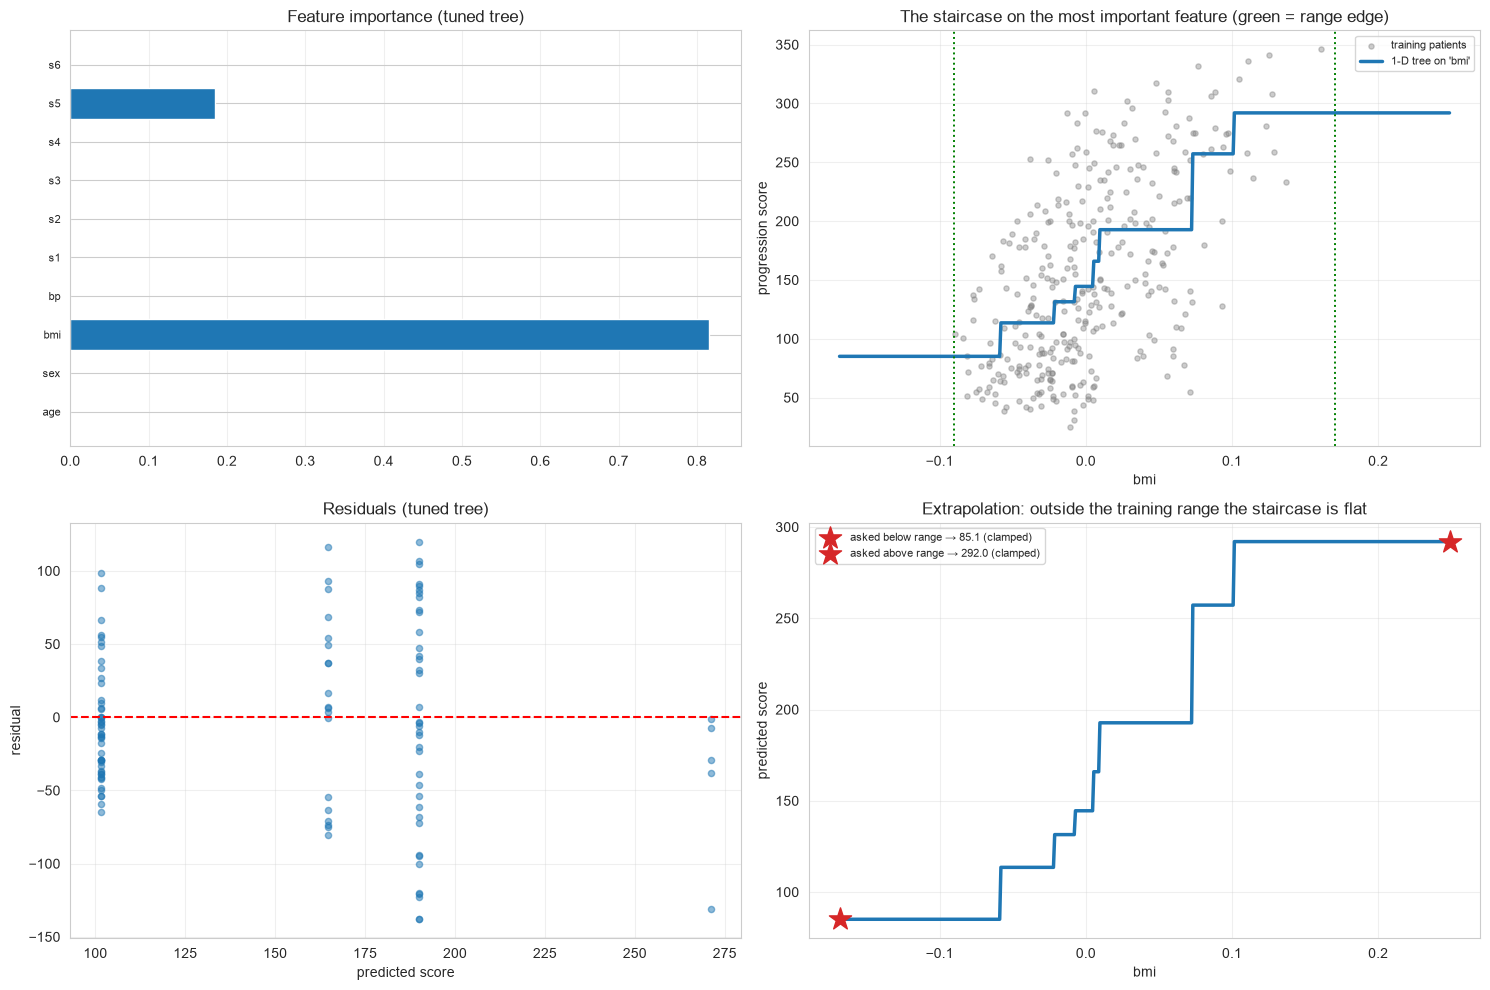

Most important feature: "bmi" (81.6% of total impurity credit)

❌ Extrapolation probe: below the training minimum the 1-D tree returns 85.1,
   above the maximum it returns 292.0 — the edge leaves means, repeated forever.
   No trend is modeled beyond the data. That is the §4 avoid row, demonstrated.


In [23]:
# Inspecting the tuned tree: importance, the 1-D staircase, residuals, the extrapolation clamp
feat_idx_db = int(np.argmax(tree_db.feature_importances_))
best_db_feature = diab.feature_names[feat_idx_db]

tree_1d_db = DecisionTreeRegressor(max_depth=3, random_state=42).fit(
    Xdb_tr[:, [feat_idx_db]], ydb_tr)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].barh(range(len(diab.feature_names)), tree_db.feature_importances_, color='#1f77b4')
axes[0, 0].set_yticks(range(len(diab.feature_names)))
axes[0, 0].set_yticklabels(diab.feature_names, fontsize=8)
axes[0, 0].set_title('Feature importance (tuned tree)')
axes[0, 0].grid(True, alpha=0.3, axis='x')

span_db = Xdb[:, feat_idx_db].max() - Xdb[:, feat_idx_db].min()
grid_1d = np.linspace(Xdb[:, feat_idx_db].min() - 0.3 * span_db,
                      Xdb[:, feat_idx_db].max() + 0.3 * span_db, 500).reshape(-1, 1)
axes[0, 1].scatter(Xdb_tr[:, feat_idx_db], ydb_tr, s=14, alpha=0.4, color='gray',
                   label='training patients')
axes[0, 1].plot(grid_1d, tree_1d_db.predict(grid_1d), color='#1f77b4', lw=2.5,
                label="1-D tree on '" + best_db_feature + "'")
for edge_db in (Xdb[:, feat_idx_db].min(), Xdb[:, feat_idx_db].max()):
    axes[0, 1].axvline(edge_db, color='green', ls=':', lw=1.4)
axes[0, 1].set_xlabel(best_db_feature)
axes[0, 1].set_ylabel('progression score')
axes[0, 1].set_title('The staircase on the most important feature (green = range edge)')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

pred_db_te = tree_db.predict(Xdb_te)
resid_db = ydb_te - pred_db_te
axes[1, 0].scatter(pred_db_te, resid_db, alpha=0.5, s=20)
axes[1, 0].axhline(0, color='red', ls='--', lw=1.5)
axes[1, 0].set_xlabel('predicted score')
axes[1, 0].set_ylabel('residual')
axes[1, 0].set_title('Residuals (tuned tree)')
axes[1, 0].grid(True, alpha=0.3)

below_db = tree_1d_db.predict(np.array([[Xdb[:, feat_idx_db].min() - 0.2 * span_db]]))[0]
above_db = tree_1d_db.predict(np.array([[Xdb[:, feat_idx_db].max() + 0.2 * span_db]]))[0]
axes[1, 1].plot(grid_1d, tree_1d_db.predict(grid_1d), color='#1f77b4', lw=2.5)
axes[1, 1].scatter([grid_1d[0, 0]], [below_db], marker='*', s=280, color='#d62728', zorder=5,
                   label=f'asked below range → {below_db:.1f} (clamped)')
axes[1, 1].scatter([grid_1d[-1, 0]], [above_db], marker='*', s=280, color='#d62728', zorder=5,
                   label=f'asked above range → {above_db:.1f} (clamped)')
axes[1, 1].set_xlabel(best_db_feature)
axes[1, 1].set_ylabel('predicted score')
axes[1, 1].set_title('Extrapolation: outside the training range the staircase is flat')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Most important feature: "{best_db_feature}" '
      f'({tree_db.feature_importances_.max():.1%} of total impurity credit)')
print()
print(f'❌ Extrapolation probe: below the training minimum the 1-D tree returns {below_db:.1f},')
print(f'   above the maximum it returns {above_db:.1f} — the edge leaves means, repeated forever.')
print('   No trend is modeled beyond the data. That is the §4 avoid row, demonstrated.')

---

## 11. Comparison with Other Algorithms

### When to Choose Decision Trees vs Alternatives

| Aspect | Decision Tree | Linear Models (01–02) | SVM (05) | Random Forest (04) | KNN (07) | Gaussian NB (06) |
|---|---|---|---|---|---|---|
| **Interpretability** | ⭐⭐⭐⭐⭐ (drawable rules) | ⭐⭐⭐⭐ (coefficients) | ⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐ |
| **Training Speed** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ (store) | ⭐⭐⭐⭐⭐ |
| **Prediction Speed** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Non-linear Boundaries** | ⭐⭐⭐⭐ (staircase) | ⭐ | ⭐⭐⭐⭐⭐ (kernels) | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ |
| **Feature Scaling** | ❌ not needed | ✅ | ✅ | ❌ | ✅ | ❌ |
| **Extrapolation** | ❌ clamps | ✅ | ❌ | ❌ | ❌ | ❌ |
| **Overfitting Risk (single model)** | High if unconstrained | Low | Medium | Low (ensembled) | Medium | Low |
| **Mixed Feature Types** | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ |
| **High-Dim Sparse (text)** | ⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ (linear) | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ |

The tree's unique row is the first one: it is the only model here whose *entire* fitted logic can
be printed and audited. Its cost is variance (§5) — which its own ensembles (04, 08–11) convert
into the industry's default tabular learner. The benchmark below puts numbers on the trade.

### Practical Comparison

The same protocol as notebook 05's §11: 5-fold stratified CV, one accuracy number per
(algorithm, dataset) pair; three geometries — blobs that a line can cut, interleaved moons that a
line cannot, and the real breast-cancer data. Scaled pipelines for the distance-based models;
trees and forests see raw features, as is their right.

ALGORITHM COMPARISON: 5-FOLD CV ACCURACY ON THREE GEOMETRIES
Dataset              Blobs (separable)  Breast cancer (real)  Moons (interleaved)
Algorithm                                                                        
Decision Tree                    0.940                0.9192                0.950
Gaussian NB                      0.960                0.9385                0.852
KNN (k=7)                        0.968                0.9649                0.966
Logistic Regression              0.960                0.9737                0.860
Random Forest                    0.962                0.9543                0.962

             Dataset           Algorithm  CV accuracy  ± std  CV time (s)
   Blobs (separable) Logistic Regression       0.9600 0.0089       0.0245
   Blobs (separable)       Decision Tree       0.9400 0.0179       0.0136
   Blobs (separable)       Random Forest       0.9620 0.0098       0.3746
   Blobs (separable)           KNN (k=7)       0.9680 0.0040       0

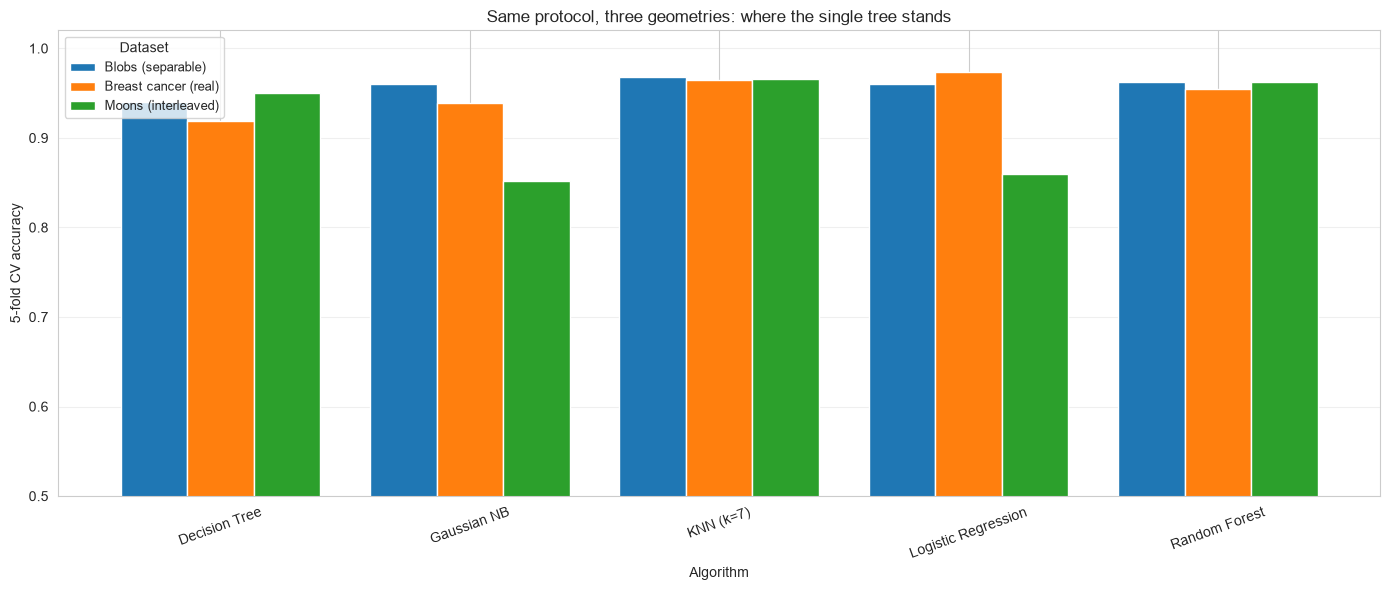

💡 Read the Decision Tree row against its own ensemble: the forest beats the single
   tree on every geometry — that is §5 variance, averaged away (notebook 04).
   Against the rivals, the single tree is respectable everywhere with zero preprocessing.


In [24]:
# Same CV protocol across three geometries — the tree family against its usual rivals
bc_cmp = load_breast_cancer()
datasets_cmp = {
    'Blobs (separable)': make_blobs(n_samples=500, centers=2, cluster_std=2.8, random_state=42),
    'Moons (interleaved)': make_moons(n_samples=500, noise=0.22, random_state=42),
    'Breast cancer (real)': (bc_cmp.data, bc_cmp.target),
}


def cmp_estimators():
    return {
        'Logistic Regression': Pipeline([('sc', StandardScaler()),
                                         ('clf', LogisticRegression(max_iter=2000))]),
        'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'KNN (k=7)': Pipeline([('sc', StandardScaler()),
                               ('clf', KNeighborsClassifier(n_neighbors=7))]),
        'Gaussian NB': GaussianNB(),
    }


rows_bench = []
cv_bench = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for dname, (Xd_b, yd_b) in datasets_cmp.items():
    for ename, est in cmp_estimators().items():
        t0 = time.perf_counter()
        scores_b = cross_val_score(est, Xd_b, yd_b, cv=cv_bench, scoring='accuracy', n_jobs=-1)
        t_b = time.perf_counter() - t0
        rows_bench.append({'Dataset': dname, 'Algorithm': ename,
                           'CV accuracy': scores_b.mean(), '± std': scores_b.std(),
                           'CV time (s)': t_b})
bench_df = pd.DataFrame(rows_bench)

pivot_bench = bench_df.pivot(index='Algorithm', columns='Dataset', values='CV accuracy')
print('=' * 60)
print('ALGORITHM COMPARISON: 5-FOLD CV ACCURACY ON THREE GEOMETRIES')
print('=' * 60)
print(pivot_bench.round(4).to_string())
print()
print(bench_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

fig, ax = plt.subplots(figsize=(14, 6))
pivot_bench.plot(kind='bar', ax=ax, rot=20, width=0.8)
ax.set_ylabel('5-fold CV accuracy')
ax.set_ylim(0.5, 1.02)
ax.set_title('Same protocol, three geometries: where the single tree stands')
ax.legend(title='Dataset', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 Read the Decision Tree row against its own ensemble: the forest beats the single')
print('   tree on every geometry — that is §5 variance, averaged away (notebook 04).')
print('   Against the rivals, the single tree is respectable everywhere with zero preprocessing.')

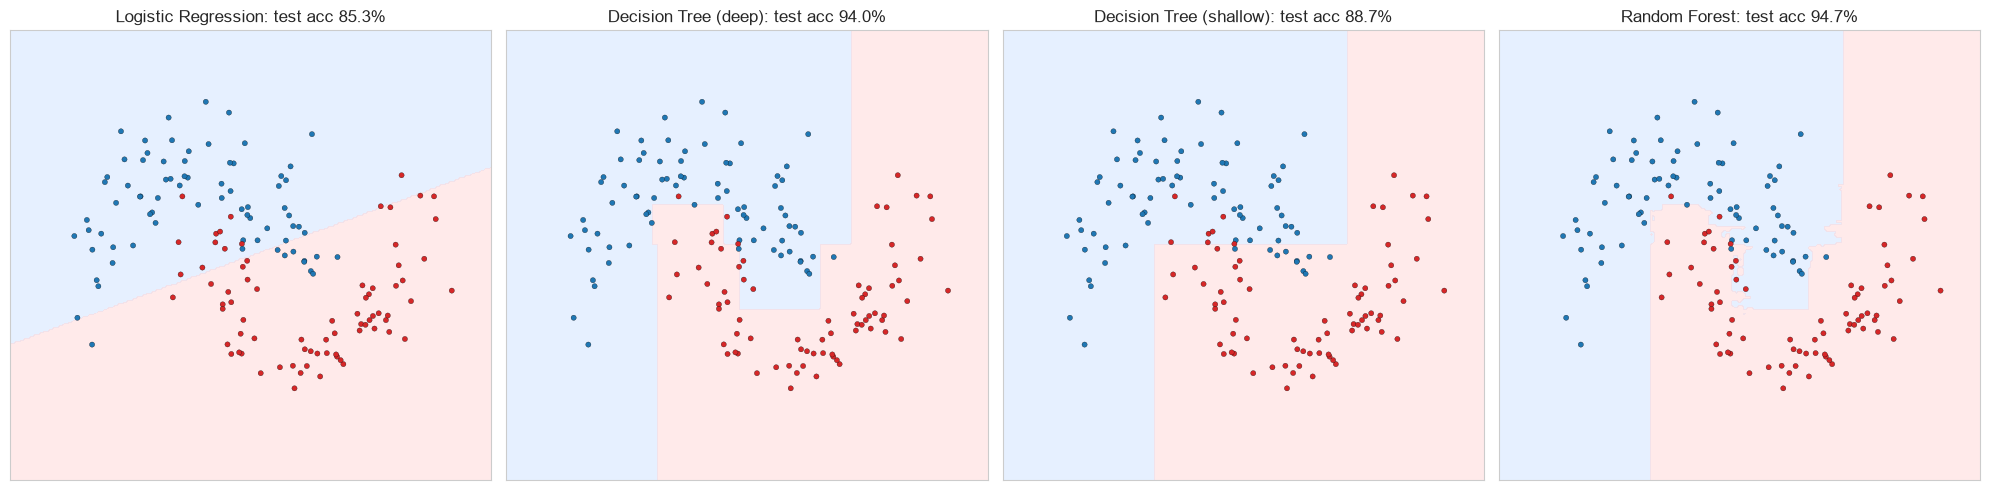

💡 Same lesson as §1, now against rivals: logistic regression draws one straight line and
   cannot bend; the shallow tree offers a few rectangles; the deep tree follows the
   crescents with a staircase; the forest reaches the same shape with calmer edges.
   Every boundary here is made of the colors the model was willing to commit to.


In [25]:
# The boundary shapes behind the numbers: four families on the interleaved geometry
X_mo, y_mo = make_moons(n_samples=500, noise=0.22, random_state=42)
Xmo_tr, Xmo_te, ymo_tr, ymo_te = train_test_split(X_mo, y_mo, test_size=0.3,
                                                  stratify=y_mo, random_state=42)
families_mo = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
                                     ('clf', LogisticRegression(max_iter=2000))]),
    'Decision Tree (deep)': DecisionTreeClassifier(min_samples_leaf=6, random_state=42),
    'Decision Tree (shallow)': DecisionTreeClassifier(max_depth=3, min_samples_leaf=5,
                                                      random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

pad_mo = 0.4
xx_mo, yy_mo = np.meshgrid(
    np.linspace(X_mo[:, 0].min() - pad_mo, X_mo[:, 0].max() + pad_mo, 250),
    np.linspace(X_mo[:, 1].min() - pad_mo, X_mo[:, 1].max() + pad_mo, 250),
)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, est) in zip(axes, families_mo.items()):
    est.fit(Xmo_tr, ymo_tr)
    Z_mo = est.predict(np.c_[xx_mo.ravel(), yy_mo.ravel()]).reshape(xx_mo.shape)
    ax.contourf(xx_mo, yy_mo, Z_mo, levels=[-0.5, 0.5, 1.5], colors=['#cfe2ff', '#ffd6d6'], alpha=0.5)
    ax.scatter(Xmo_te[:, 0], Xmo_te[:, 1], c=np.where(ymo_te == 1, '#d62728', '#1f77b4'),
               s=14, edgecolors='k', linewidths=0.2)
    ax.set_title(f'{name}: test acc {est.score(Xmo_te, ymo_te):.1%}')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print('💡 Same lesson as §1, now against rivals: logistic regression draws one straight line and')
print('   cannot bend; the shallow tree offers a few rectangles; the deep tree follows the')
print('   crescents with a staircase; the forest reaches the same shape with calmer edges.')
print('   Every boundary here is made of the colors the model was willing to commit to.')

---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
    - Morgan, J. N., & Sonquist, J. A. (1963). \"Problems in the Analysis of Survey Data, and a Proposal.\" *JASA*, 58: AID, the first recursive-partitioning program
    - **Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*.** Wadsworth: CART — binary splits, Gini, regression trees, cost-complexity pruning
    - **Quinlan, J. R. (1986). \"Induction of Decision Trees.\"** *Machine Learning*, 1(1): ID3 and entropy-based splitting
    - Quinlan, J. R. (1993). *C4.5: Programs for Machine Learning*. Morgan Kaufmann
2. **The Ensembles Built On It**:
    - Breiman, L. (2001). \"Random Forests.\" *Machine Learning*, 45(1): bagging over trees (notebook 04)
    - Friedman, J. H. (2001). \"Greedy Function Approximation: A Gradient Boosting Machine.\" *Annals of Statistics*: boosted trees (notebook 08)
    - Chen, T., & Guestrin, C. (2016). \"XGBoost: A Scalable Tree Boosting System.\" *KDD '16* (notebook 09)
3. **Modern Textbooks**:
    - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*, Chapters 9–10 (trees, bagging, boosting)
    - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*, Chapter 8 (free PDF at statlearning.com)
    - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chapter 14.4

### 🌐 Online Resources

- [Scikit-learn Decision Trees user guide](https://scikit-learn.org/stable/modules/tree.html): the main reference — tips, `tree_` internals, cost-complexity pruning, missing values
- [DecisionTreeClassifier API](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and [DecisionTreeRegressor API](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- [plot_tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) and [export_text](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html): the two rendering tools used in this notebook
- StatQuest's Decision Tree videos on YouTube: the friendliest walkthrough of Gini and splits
- [A Visual Introduction to Machine Learning, Part 1](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/): the partition view animated
- [Decision tree visualization at explained.ai](https://explained.ai/decision-tree-viz/)

### 📊 Key Concepts to Master

- **Recursive partitioning**: greedy splits, `feature ≤ threshold`, nothing revisited
- **Impurity**: Gini vs entropy — same optimum, near-identical trees (§2, §5)
- **Variance reduction**: the regression analogue; leaves are means, predictions are staircases
- **Stopping rules**: `max_depth`, `min_samples_split`, purity, no-positive-gain
- **Cost-complexity pruning**: grow freely, cut with α, choose α by CV (§7)
- **Instability**: resampling changes the tree (§5); ensembles average it away (04, 08)
- **Scale-invariance**: no scaling, ever (§3)
- **Probability coarseness**: `predict_proba` = leaf fractions (§10)

### 🔗 Related Notebooks and Repository Files

- `01_linear_regression.ipynb` / `02_logistic_regression.ipynb`: the linear baselines trees are contrasted with
- `04_random_forest.ipynb`: the variance fix — bagged ensembles of these exact trees
- `05_support_vector_machines.ipynb`: the smooth, kernel-based alternative (same moons, same protocol)
- `08_gradient_boosting.ipynb` / `09_xgboost.ipynb`: boosted trees — the other family built on this base
- `src/models/tree_models.py`: the from-scratch twin used in §5 (classifier + regressor)
- `tests/models/test_tree_models.py`: the behavioral tests pinning the twin's conventions

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: a tree partitions feature space with axis-aligned cuts, each chosen greedily to
   maximize impurity reduction (Gini/entropy for classification, variance reduction for regression)
2. **Math**: gain $= I(\text{parent}) - \text{weighted child impurity}$; leaves store the majority
   class, class fractions, or the mean target — and nothing else
3. **Geometry**: every boundary is a staircase; depth buys resolution at the price of variance
4. **Assumptions**: almost none on distributions — but axis-aligned cuts, stable labels, and
   enough rows per leaf are load-bearing
5. **Implementation**: the twin exposes the recursion as walkable `Node` objects; hand-tracing a
   prediction and bootstrapping the fit made the mechanics and the variance concrete
6. **Hyperparameters**: `max_depth` and `min_samples_leaf` first; `ccp_alpha` pruning often beats
   hand-capping; criterion is rarely the lever (§5 measured it)
7. **Practice**: breast cancer with audited per-patient rules and blocky probabilities; diabetes
   with the staircase, the tuned-vs-deep contrast, and the extrapolation clamp

### When to Use a Decision Tree

✅ **Use when**:
- the model itself must be explainable — rules, a drawn flowchart, per-decision audits
- tabular data with mixed feature types and no appetite for preprocessing
- threshold effects, jumps, and interactions dominate the signal
- you need a fast, honest baseline — or the base learner for an ensemble

❌ **Avoid (as a single tree) when**:
- smooth predictions or extrapolation are required (linear models instead)
- the dataset is small and noisy (high variance)
- best accuracy is the goal — its ensembles (04, 08–11) are
- features are sparse and high-dimensional (linear models / Naive Bayes 06)

### Best Practices Checklist

- ✅ always set `max_depth` or prune with a CV-chosen `ccp_alpha` (never ship `None` unwatched)
- ✅ tune with cross-validation on training data only; report the test set once
- ✅ check the train-test gap; shrink depth / raise leaf size when it exceeds ~0.10
- ✅ no scaling — but impute missing values inside a pipeline
- ✅ cross-check importances with `permutation_importance`; drop ID-like columns first
- ✅ handle imbalance with `class_weight='balanced'` and per-class metrics
- ✅ for stakeholders: `export_text` + `plot_tree` — the model is the documentation

### Advantages vs Disadvantages

**Advantages:**
- ✅ fully interpretable — drawable, exportable, auditable per decision
- ✅ no feature scaling; mixed feature types handled natively
- ✅ non-linearities, threshold effects, and interactions captured automatically
- ✅ native multi-class (one tree, no tournaments)
- ✅ fast training and O(depth) prediction

**Disadvantages:**
- ❌ high variance — resampling rebuilds the tree (§5)
- ❌ overfits without constraints or pruning
- ❌ axis-aligned only; rotated structure costs many cuts
- ❌ piecewise-constant predictions; cannot extrapolate
- ❌ coarse, quantized probabilities from leaf fractions
- ❌ greedy, not globally optimal

### Unique Characteristic: The Model Is the Flowchart

Every other model in this series hides its logic behind a function. A tree *is* its logic: each
internal node is a rule, each leaf a verdict with a confidence you can read off the sample counts.
That is why it survives in regulated domains and why every ensemble literature begins with it.

### Next Steps

1. **Practice**: refit §7's tuning on your own tabular data — depth sweep, leaf sweep, α path
2. **Diagnose**: the train-test gap, leaf sizes, and importance sanity (`permutation_importance`)
3. **Compare**: run the §11 protocol on your problem before reaching for the library models
4. **Read**: notebook 04 (the variance fix), then 08–11 (boosting the same recursion)
5. **Explore** `src/models/tree_models.py` and `tests/models/test_tree_models.py` to see exactly
   which behaviors the twin pins down

---

**Congratulations!** You can now grow a tree by hand-arithmetic, walk a prediction down its nodes,
tune it with CV and pruning, and say precisely when the staircase is the right answer. 🌳🎉

**Remember**: a tree is many small rectangles pretending to be a curve. Constrain the pretending
(depth, leaves, α), choose with cross-validation, and let ensembles smooth what a single tree
cannot.